# GCP2 Notes: Machine learning regionalization for GR4J

## Notebook purpose
This notebook compares several machine learning approaches for regionalizing calibrated GR4J parameters from catchment descriptors. The target parameters are `x1`, `x2`, `x3`, and `x4`, and the methods compared here are:

- **Linear Regression Model (LRM)**
- **Random Forest (RF)**
- **Support Vector Regression (SVR)**

The notebook is designed to identify useful descriptor combinations on the training set and then evaluate each method on a hidden 30% of catchments.

## Overall workflow
The analysis proceeds in a structured sequence:
1. build a common data-processing and evaluation framework,
2. search descriptor combinations for each method,
3. tune promising model configurations,
4. fit final models on the training catchments,
5. predict the hidden test catchments,
6. summarize hidden-test metrics, and
7. create comparison and descriptor-selection visualizations.

## Why this organization is helpful
A major strength of this notebook is that all three methods share the same data split and the same evaluation structure. That makes the comparison more fair, because differences in performance are more likely to come from the model choice rather than from inconsistent preprocessing or testing conditions.


## Common setup for all machine learning methods

### Purpose of this block
This first code cell builds the shared framework used by all later model-specific sections. It is the backbone of the notebook because every method relies on the same inputs, helper functions, descriptor pools, and hidden-test split.

### What happens in this block

#### 1. Package setup and imports
The notebook installs or imports the packages needed for:
- data manipulation,
- plotting,
- model fitting,
- cross-validation,
- preprocessing, and
- hyperparameter search.

This ensures the later cells can focus on the regionalization workflow rather than repeating setup tasks.

#### 2. User settings
Key experiment settings are centralized here, including:
- file paths for calibrated GR4J parameters and descriptors,
- ID columns used to merge files,
- the GR4J target parameters,
- the NSE-based filtering column,
- the threshold used to keep acceptable basins,
- the hidden test fraction,
- the random seed, and
- the number of CV folds.

Putting these values in one place improves transparency and makes the notebook easier to reproduce.

#### 3. Descriptor pools
Two descriptor pools are defined:
- a **paper-mimic pool**, which includes hydrologic signatures and is useful for reproducing the style of the class analysis, and
- a **no-flow pool**, which removes streamflow-derived signatures and is more realistic for truly ungauged prediction settings.

The code also stores descriptor categories and colors so later plots can show which types of descriptors are being selected.

#### 4. Helper functions
A large set of reusable functions is defined here. These functions handle tasks such as:
- reading and harmonizing tables,
- transforming or back-transforming targets when needed,
- computing performance metrics,
- building preprocessing/model pipelines,
- measuring multicollinearity with condition index,
- producing cross-validated predictions for one descriptor combination,
- searching descriptor combinations systematically,
- tuning the best combinations,
- fitting final models and predicting hidden test catchments,
- saving selected combinations, and
- generating plots.

This modular design is especially important in a long notebook. It reduces duplicated code and makes each later method cell much easier to read.

#### 5. Load, merge, filter, and split
Finally, the block reads the parameter and descriptor tables, converts key columns to numeric types, keeps only available descriptors, filters out weakly calibrated basins, and creates the 70/30 train-test split.

This final step is crucial because all three methods must be evaluated on the **same hidden set** for the comparison to be meaningful.

### Why this block matters
Everything that follows depends on this shared setup. By standardizing preprocessing, descriptor handling, and evaluation, the notebook creates a clean experimental foundation for comparing LRM, RF, and SVR.


In [6]:
# ============================================================
# COMMON SETUP FOR GR4J REGIONALIZATION
# ============================================================
# Install required packages first
%pip install -q scikit-learn pandas numpy matplotlib openpyxl
from pathlib import Path
from itertools import combinations
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


warnings.filterwarnings("ignore")


# ============================================================
# 1. USER SETTINGS — EDIT THESE
# ============================================================

PARAMS_FILE = "gr4j_sceua_results.csv"   # file with catchment, x1, x2, x3, x4, NSE_cal, NSE_val
DESCRIPTORS_FILE = "descriptors.csv"         # file with catchment descriptors

# These can have different names in the two files.
PARAM_ID_COL = "catchment"   # from GR4J results file
DESC_ID_COL = "gauge_id"     # from descriptor file; change if your descriptor ID column has another name

TARGET_COLS = ["x1", "x2", "x3", "x4"]

# use calibration NSE.
NSE_FILTER_COL = "NSE_cal"

MIN_NSE = 0.50
TEST_SIZE = 0.30
RANDOM_STATE = 42
CV_FOLDS = 3

OUTDIR = Path("gr4j_final_output")
OUTDIR.mkdir(exist_ok=True)


# ============================================================
# 2. DESCRIPTOR POOLS
# ============================================================

# Main paper-mimic pool: includes hydrologic signatures.
PAPER_MIMIC_DESCRIPTOR_POOL = [
    "p_mean",
    "p_seasonality",
    "frac_snow",
    "aridity",
    "high_prec_dur",

    "runoff_ratio",
    "baseflow_index",
    "q5",
    "q95",
    "hfd_mean",

    "geol_permeability",
    "soil_porosity",
    "slope_mean",
    "area_gages2",
]

# More realistic ungauged-basin pool: excludes streamflow-derived hydrologic signatures.
# Use this later for transfer to another country.
NO_FLOW_DESCRIPTOR_POOL = [
    "p_mean",
    "pet_mean",
    "p_seasonality",
    "frac_snow",
    "aridity",
    "high_prec_dur",
    "low_prec_dur",

    "geol_permeability",
    "soil_porosity",
    "soil_conductivity",
    "soil_depth_pelletier",

    "elev_mean",
    "slope_mean",
    "area_gages2",
    "gvf_diff",
]

USE_NO_FLOW_POOL = False

if USE_NO_FLOW_POOL:
    REQUESTED_DESCRIPTOR_POOL = NO_FLOW_DESCRIPTOR_POOL
else:
    REQUESTED_DESCRIPTOR_POOL = PAPER_MIMIC_DESCRIPTOR_POOL


# Descriptor categories for paper-style colored selection plot.
DESCRIPTOR_CATEGORY = {
    # Climate indices
    "p_mean": "Climate",
    "pet_mean": "Climate",
    "p_seasonality": "Climate",
    "frac_snow": "Climate",
    "aridity": "Climate",
    "high_prec_dur": "Climate",
    "high_prec_freq": "Climate",
    "low_prec_dur": "Climate",
    "low_prec_freq": "Climate",

    # Hydrologic signatures
    "q_mean": "Hydrologic signature",
    "runoff_ratio": "Hydrologic signature",
    "slope_fdc": "Hydrologic signature",
    "baseflow_index": "Hydrologic signature",
    "stream_elas": "Hydrologic signature",
    "q5": "Hydrologic signature",
    "q95": "Hydrologic signature",
    "high_q_freq": "Hydrologic signature",
    "high_q_dur": "Hydrologic signature",
    "low_q_freq": "Hydrologic signature",
    "low_q_dur": "Hydrologic signature",
    "hfd_mean": "Hydrologic signature",

    # Soil
    "soil_depth_pelletier": "Soil",
    "soil_depth_statsgo": "Soil",
    "soil_porosity": "Soil",
    "soil_conductivity": "Soil",
    "sand_frac": "Soil",
    "silt_frac": "Soil",
    "clay_frac": "Soil",

    # Geology
    "geol_permeability": "Geology",
    "geol_porosity": "Geology",
    "geol_porostiy": "Geology",  # included in case your column has this typo

    # Topography
    "elev_mean": "Topography",
    "slope_mean": "Topography",
    "area_gages2": "Topography",

    # Land cover / vegetation
    "frac_forest": "Land cover",
    "gvf_max": "Land cover",
    "gvf_diff": "Land cover",
}

CATEGORY_COLORS = {
    "Climate": "#22a844",
    "Hydrologic signature": "#2878b5",
    "Land cover": "#d957d9",
    "Soil": "#e39139",
    "Topography": "#d62728",
    "Geology": "#9a9a9a",
    "Other": "#cccccc",
}


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def read_table(path, id_col):
    """
    Reads csv or Excel file while preserving catchment/gage IDs as strings.
    """
    path = Path(path)
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path, dtype={id_col: str})
    else:
        return pd.read_csv(path, dtype={id_col: str})


def clean_gage_id(value):
    """
    Normalizes USGS/CAMELS-style gage IDs.

    Example:
    1013500 -> 01013500
    "01013500" -> 01013500
    "1013500.0" -> 01013500
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip()

    if s.endswith(".0"):
        s = s[:-2]

    s = "".join(ch for ch in s if ch.isdigit())

    if s == "":
        return np.nan

    return s.zfill(8)


def transform_target(y, target_name):
    """
    GR4J x1, x3, and x4 are positive and usually skewed, so use log transform.
    GR4J x2 can be negative, so keep it untransformed.
    """
    y = np.asarray(y, dtype=float)

    if target_name in ["x1", "x3", "x4"]:
        if np.any(y <= 0):
            raise ValueError(
                f"{target_name} contains non-positive values. "
                "Remove or inspect those calibrations before log-transforming."
            )
        return np.log(y)

    return y.copy()


def inverse_transform_target(y_trans, target_name):
    y_trans = np.asarray(y_trans, dtype=float)

    if target_name in ["x1", "x3", "x4"]:
        return np.exp(y_trans)

    return y_trans.copy()


def paper_r2(y_true, y_pred):
    """
    R² as squared Pearson correlation, matching the paper's Eq. 6 style.
    This is not always identical to sklearn's r2_score.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) < 2:
        return np.nan

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan

    return float(np.corrcoef(y_true, y_pred)[0, 1] ** 2)


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))


def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.nanmean(y_pred - y_true))


def build_pipeline(estimator, scale=True):
    steps = [("imputer", SimpleImputer(strategy="median"))]

    if scale:
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", estimator))
    return Pipeline(steps)


def condition_index(train_df, descriptor_tuple):
    """
    Multicollinearity diagnostic for linear regression.
    The paper discusses condition index:
    < 10 weak, 10-30 moderate, > 30 high.
    """
    X = train_df[list(descriptor_tuple)].copy()
    X = X.apply(pd.to_numeric, errors="coerce")

    X_imp = SimpleImputer(strategy="median").fit_transform(X)
    X_std = StandardScaler().fit_transform(X_imp)

    singular_values = np.linalg.svd(X_std, compute_uv=False)
    smallest = np.min(singular_values)

    if smallest <= 1e-12:
        return np.inf

    return float(np.max(singular_values) / smallest)


def cv_predict_one_combo(train_df, target, descriptor_tuple, estimator, scale=True):
    """
    Cross-validated predictions for one parameter and one descriptor combination.
    CV is done only inside the 70% training data.
    """
    X = train_df[list(descriptor_tuple)].copy()
    y_raw = train_df[target].astype(float).to_numpy()
    y_trans = transform_target(y_raw, target)

    preds_raw = np.full(len(train_df), np.nan)

    cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    for train_idx, val_idx in cv.split(X):
        model = build_pipeline(clone(estimator), scale=scale)

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y_trans[train_idx]

        model.fit(X_train, y_train)

        pred_trans = model.predict(X_val)
        pred_raw = inverse_transform_target(pred_trans, target)

        preds_raw[val_idx] = pred_raw

    return preds_raw


def search_descriptor_combinations(
    train_df,
    target,
    estimator,
    method_name,
    scale=True,
    max_condition_index=None,
    descriptor_cols=None,
):
    """
    Tests all 4-descriptor combinations for one parameter and one model.
    """
    if descriptor_cols is None:
        descriptor_cols = DESCRIPTOR_COLS

    rows = []
    combos = list(combinations(descriptor_cols, 4))

    start = time.time()

    for i, combo in enumerate(combos, start=1):
        ci = np.nan

        if max_condition_index is not None:
            ci = condition_index(train_df, combo)
            if ci > max_condition_index:
                continue

        pred_cv = cv_predict_one_combo(
            train_df=train_df,
            target=target,
            descriptor_tuple=combo,
            estimator=estimator,
            scale=scale,
        )

        y_true = train_df[target].astype(float).to_numpy()

        rows.append({
            "method": method_name,
            "target": target,
            "descriptors": combo,
            "r2_cv": paper_r2(y_true, pred_cv),
            "rmse_cv": rmse(y_true, pred_cv),
            "bias_cv": bias(y_true, pred_cv),
            "condition_index": ci,
        })

        if i % 250 == 0:
            elapsed = time.time() - start
            print(f"{method_name} {target}: tested {i}/{len(combos)} combinations in {elapsed:.1f} sec")

    result = pd.DataFrame(rows)

    if len(result) == 0:
        raise RuntimeError(f"No valid descriptor combinations found for {method_name} {target}.")

    result = result.sort_values("r2_cv", ascending=False).reset_index(drop=True)
    return result


def tune_top_combinations(
    train_df,
    target,
    top_combos_df,
    estimator_class,
    param_grid,
    base_kwargs,
    method_name,
    scale,
):
    """
    Tunes hyperparameters only for the top descriptor combinations.
    This keeps SVR and RF from becoming too slow.
    """
    rows = []

    for _, combo_row in top_combos_df.iterrows():
        combo = tuple(combo_row["descriptors"])

        for params in ParameterGrid(param_grid):
            full_params = dict(base_kwargs)
            full_params.update(params)

            estimator = estimator_class(**full_params)

            pred_cv = cv_predict_one_combo(
                train_df=train_df,
                target=target,
                descriptor_tuple=combo,
                estimator=estimator,
                scale=scale,
            )

            y_true = train_df[target].astype(float).to_numpy()

            rows.append({
                "method": method_name,
                "target": target,
                "descriptors": combo,
                "params": params,
                "r2_cv": paper_r2(y_true, pred_cv),
                "rmse_cv": rmse(y_true, pred_cv),
                "bias_cv": bias(y_true, pred_cv),
            })

    tuned = pd.DataFrame(rows)
    tuned = tuned.sort_values("r2_cv", ascending=False).reset_index(drop=True)
    return tuned


def fit_final_predict(train_df, test_df, target, descriptor_tuple, estimator, scale=True):
    """
    Fits final model on full 70% training data and predicts hidden 30%.
    """
    X_train = train_df[list(descriptor_tuple)].copy()
    X_test = test_df[list(descriptor_tuple)].copy()

    y_train_raw = train_df[target].astype(float).to_numpy()
    y_train_trans = transform_target(y_train_raw, target)

    model = build_pipeline(estimator, scale=scale)
    model.fit(X_train, y_train_trans)

    pred_test_trans = model.predict(X_test)
    pred_test_raw = inverse_transform_target(pred_test_trans, target)

    return pred_test_raw, model


def evaluate_test_predictions(pred_df, method_name):
    rows = []

    for target in TARGET_COLS:
        y_true = pred_df[f"{target}_calibrated"].to_numpy(dtype=float)
        y_pred = pred_df[f"{target}_predicted"].to_numpy(dtype=float)

        rows.append({
            "method": method_name,
            "parameter": target,
            "r2_test": paper_r2(y_true, y_pred),
            "rmse_test": rmse(y_true, y_pred),
            "bias_test": bias(y_true, y_pred),
        })

    rows.append({
        "method": method_name,
        "parameter": "mean_x1_x4",
        "r2_test": np.mean([r["r2_test"] for r in rows]),
        "rmse_test": np.mean([r["rmse_test"] for r in rows]),
        "bias_test": np.mean([r["bias_test"] for r in rows]),
    })

    return pd.DataFrame(rows)


def save_selected_combos(selected_df, filename):
    save_df = selected_df.copy()
    save_df["descriptors"] = save_df["descriptors"].apply(lambda x: ", ".join(x))
    if "params" in save_df.columns:
        save_df["params"] = save_df["params"].astype(str)
    save_df.to_csv(OUTDIR / filename, index=False)


def plot_selected_descriptor_matrix(selected_df, method_name):
    """
    Paper Fig. 5(b)-style plot:
    rows = x1-METHOD1, x1-METHOD2, etc.
    columns = descriptors.
    colored squares = descriptor selected in that combination.
    """
    selected_df = selected_df.copy().reset_index(drop=True)

    n_rows = len(selected_df)
    n_cols = len(DESCRIPTOR_COLS)

    fig_width = max(11, n_cols * 0.58)
    fig_height = max(5, n_rows * 0.35)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    for i, row in selected_df.iterrows():
        selected = set(row["descriptors"])

        for j, desc in enumerate(DESCRIPTOR_COLS):
            if desc in selected:
                category = DESCRIPTOR_CATEGORY.get(desc, "Other")
                color = CATEGORY_COLORS.get(category, CATEGORY_COLORS["Other"])
            else:
                color = "white"

            rect = Rectangle(
                (j, i),
                1,
                1,
                facecolor=color,
                edgecolor="0.55",
                linewidth=0.8,
            )
            ax.add_patch(rect)

        ax.text(
            n_cols + 0.25,
            i + 0.5,
            f"{row['r2_cv']:.2f}",
            va="center",
            ha="left",
            fontsize=9,
        )

    row_labels = [
        f"{row['target']}-{method_name}{int(row['rank'])}"
        for _, row in selected_df.iterrows()
    ]

    ax.set_xlim(0, n_cols + 1.5)
    ax.set_ylim(0, n_rows)
    ax.invert_yaxis()

    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(DESCRIPTOR_COLS, rotation=90, fontsize=9)

    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(row_labels, fontsize=9)

    ax.text(n_cols + 0.25, -0.4, "R²", fontsize=10, fontweight="bold")

    ax.set_title(f"Selected four-descriptor combinations: {method_name}", fontsize=13)

    legend_items = [
        Patch(facecolor=color, edgecolor="0.55", label=cat)
        for cat, color in CATEGORY_COLORS.items()
        if cat != "Other"
    ]
    ax.legend(
        handles=legend_items,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=3,
        frameon=False,
    )

    ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig(OUTDIR / f"{method_name}_selected_descriptors_matrix.png", dpi=300)
    plt.close()


def plot_parameter_scatter(pred_df, method_name):
    """
    Paper Fig. 5(c)-style calibrated-vs-predicted parameter scatter plots.
    """
    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    axes = axes.ravel()

    for ax, target in zip(axes, TARGET_COLS):
        y_true = pred_df[f"{target}_calibrated"].to_numpy(dtype=float)
        y_pred = pred_df[f"{target}_predicted"].to_numpy(dtype=float)

        r2 = paper_r2(y_true, y_pred)
        this_rmse = rmse(y_true, y_pred)
        this_bias = bias(y_true, y_pred)

        ax.scatter(
            y_true,
            y_pred,
            s=26,
            facecolors="none",
            edgecolors="red",
            alpha=0.75,
        )

        low = np.nanmin([np.nanmin(y_true), np.nanmin(y_pred)])
        high = np.nanmax([np.nanmax(y_true), np.nanmax(y_pred)])

        ax.plot([low, high], [low, high], linestyle="--", color="gray", linewidth=1)

        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

        ax.set_title(f"{target} - {method_name}")
        ax.set_xlabel(f"Calibrated {target}")
        ax.set_ylabel(f"Predicted {target}")

        ax.text(
            0.05,
            0.95,
            f"R² = {r2:.2f}\nRMSE = {this_rmse:.2f}\nBias = {this_bias:.2f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85),
        )

    fig.suptitle(f"Hidden 30% test set: calibrated vs predicted GR4J parameters", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTDIR / f"{method_name}_calibrated_vs_predicted_scatter.png", dpi=300)
    plt.close()


# ============================================================
# 4. LOAD, MERGE, FILTER, SPLIT
# ============================================================

params_df = read_table(PARAMS_FILE, PARAM_ID_COL)
desc_df = read_table(DESCRIPTORS_FILE, DESC_ID_COL)

params_df["_merge_id"] = params_df[PARAM_ID_COL].apply(clean_gage_id)
desc_df["_merge_id"] = desc_df[DESC_ID_COL].apply(clean_gage_id)

desc_df = desc_df.drop_duplicates("_merge_id")

df = params_df.merge(
    desc_df,
    on="_merge_id",
    how="inner",
    suffixes=("", "_desc"),
)

print(f"Rows in parameter file: {len(params_df)}")
print(f"Rows in descriptor file: {len(desc_df)}")
print(f"Rows after merge: {len(df)}")

if len(df) < 500:
    print("WARNING: merged row count is lower than expected. Check ID formatting and ID column names.")

if NSE_FILTER_COL not in df.columns:
    raise ValueError(
        f"{NSE_FILTER_COL} not found. Available NSE-like columns: "
        f"{[c for c in df.columns if 'NSE' in c or 'nse' in c]}"
    )

# Convert important fields to numeric.
for col in TARGET_COLS + [NSE_FILTER_COL] + REQUESTED_DESCRIPTOR_POOL:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep only descriptors that are actually present.
DESCRIPTOR_COLS = [c for c in REQUESTED_DESCRIPTOR_POOL if c in df.columns]
missing_descriptors = [c for c in REQUESTED_DESCRIPTOR_POOL if c not in df.columns]

print("\nUsing descriptor columns:")
print(DESCRIPTOR_COLS)

if missing_descriptors:
    print("\nMissing requested descriptors, skipped:")
    print(missing_descriptors)

if len(DESCRIPTOR_COLS) < 4:
    raise ValueError("Fewer than 4 descriptor columns were found. Check descriptor names.")

# Filter to catchments where calibrated GR4J performance is acceptable.
required_cols = TARGET_COLS + [NSE_FILTER_COL]
df = df.dropna(subset=required_cols).copy()
df = df[df[NSE_FILTER_COL] >= MIN_NSE].copy()

print(f"\nCatchments after {NSE_FILTER_COL} >= {MIN_NSE}: {len(df)}")

# Split catchments into 70% training and 30% hidden test.
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training catchments: {len(train_df)}")
print(f"Hidden test catchments: {len(test_df)}")
print(f"Number of 4-descriptor combinations: {len(list(combinations(DESCRIPTOR_COLS, 4)))}")

Note: you may need to restart the kernel to use updated packages.
Rows in parameter file: 666
Rows in descriptor file: 671
Rows after merge: 666

Using descriptor columns:
['p_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_dur', 'runoff_ratio', 'baseflow_index', 'q5', 'q95', 'hfd_mean', 'geol_permeability', 'soil_porosity', 'slope_mean', 'area_gages2']

Catchments after NSE_cal >= 0.5: 423
Training catchments: 296
Hidden test catchments: 127
Number of 4-descriptor combinations: 1001


## Linear Regression regionalization

### Purpose of this block
This section applies a linear regression approach to estimate GR4J parameters from descriptor combinations. It provides the simplest and most interpretable benchmark among the machine learning methods.

### What the code is doing
For each target parameter (`x1`, `x2`, `x3`, `x4`), the workflow:
1. searches candidate 4-descriptor combinations on the training set,
2. evaluates them with cross-validation,
3. saves the full search results to disk,
4. keeps the top-ranked combinations,
5. fits the final linear model using the selected descriptor set, and
6. predicts the hidden 30% test catchments.

The code also stores the selected combinations and hidden-test metrics in output tables for later comparison with RF and SVR.

### Why linear regression is included
Linear regression is useful because it is:
- straightforward to interpret,
- computationally efficient, and
- a good baseline for judging whether more flexible models are truly adding value.

If LRM performs nearly as well as more complex methods, that is a meaningful result because a simpler model is often easier to explain and defend in a report.


In [7]:
# ============================================================
# LINEAR REGRESSION REGIONALIZATION
# ============================================================

METHOD_NAME = "LRM"

linear_selected_rows = []
linear_predictions = test_df[["_merge_id", PARAM_ID_COL, NSE_FILTER_COL]].copy()

for target in TARGET_COLS:
    print(f"\n===== {METHOD_NAME}: searching descriptor combinations for {target} =====")

    estimator = LinearRegression()

    search_df = search_descriptor_combinations(
        train_df=train_df,
        target=target,
        estimator=estimator,
        method_name=METHOD_NAME,
        scale=True,
        max_condition_index=30,
        descriptor_cols=DESCRIPTOR_COLS,
    )

    # Save every tested combination.
    search_save = search_df.copy()
    search_save["descriptors"] = search_save["descriptors"].apply(lambda x: ", ".join(x))
    search_save.to_csv(OUTDIR / f"{METHOD_NAME}_{target}_all_combinations.csv", index=False)

    top4 = search_df.head(4).copy()

    for rank, (_, row) in enumerate(top4.iterrows(), start=1):
        linear_selected_rows.append({
            "method": METHOD_NAME,
            "target": target,
            "rank": rank,
            "descriptors": tuple(row["descriptors"]),
            "params": {},
            "r2_cv": row["r2_cv"],
            "rmse_cv": row["rmse_cv"],
            "bias_cv": row["bias_cv"],
            "condition_index": row["condition_index"],
        })

    best_combo = tuple(top4.iloc[0]["descriptors"])

    pred_test, fitted_model = fit_final_predict(
        train_df=train_df,
        test_df=test_df,
        target=target,
        descriptor_tuple=best_combo,
        estimator=LinearRegression(),
        scale=True,
    )

    linear_predictions[f"{target}_calibrated"] = test_df[target].astype(float).to_numpy()
    linear_predictions[f"{target}_predicted"] = pred_test

linear_selected_df = pd.DataFrame(linear_selected_rows)
linear_metrics_df = evaluate_test_predictions(linear_predictions, METHOD_NAME)

save_selected_combos(linear_selected_df, f"{METHOD_NAME}_selected_top4_combinations.csv")
linear_predictions.to_csv(OUTDIR / f"{METHOD_NAME}_hidden30_predictions.csv", index=False)
linear_metrics_df.to_csv(OUTDIR / f"{METHOD_NAME}_hidden30_metrics.csv", index=False)

plot_selected_descriptor_matrix(linear_selected_df, METHOD_NAME)
plot_parameter_scatter(linear_predictions, METHOD_NAME)

print("\nLinear regression hidden-30% metrics:")
print(linear_metrics_df)


===== LRM: searching descriptor combinations for x1 =====
LRM x1: tested 250/1001 combinations in 1.1 sec
LRM x1: tested 500/1001 combinations in 2.3 sec
LRM x1: tested 750/1001 combinations in 3.4 sec
LRM x1: tested 1000/1001 combinations in 4.5 sec

===== LRM: searching descriptor combinations for x2 =====
LRM x2: tested 250/1001 combinations in 1.2 sec
LRM x2: tested 500/1001 combinations in 2.3 sec
LRM x2: tested 750/1001 combinations in 3.4 sec
LRM x2: tested 1000/1001 combinations in 4.6 sec

===== LRM: searching descriptor combinations for x3 =====
LRM x3: tested 250/1001 combinations in 1.2 sec
LRM x3: tested 500/1001 combinations in 2.4 sec
LRM x3: tested 750/1001 combinations in 3.5 sec
LRM x3: tested 1000/1001 combinations in 4.6 sec

===== LRM: searching descriptor combinations for x4 =====
LRM x4: tested 250/1001 combinations in 1.1 sec
LRM x4: tested 500/1001 combinations in 2.3 sec
LRM x4: tested 750/1001 combinations in 3.4 sec
LRM x4: tested 1000/1001 combinations in 

## Random Forest regionalization

### Purpose of this block
This section fits a Random Forest model for each GR4J parameter. RF is included to capture nonlinear relationships and interactions among descriptors that a linear model may miss.

### What the code is doing
The workflow is intentionally staged to balance thoroughness with runtime:

#### 1. Fast screening stage
A smaller Random Forest configuration is first used to screen all candidate 4-descriptor combinations. This provides a practical way to explore a large search space without fully tuning every possible combination.

#### 2. Focused tuning stage
Only the top-ranked combinations are carried forward into a more serious hyperparameter search. The tuning grid adjusts settings such as:
- number of trees,
- number of features considered at each split, and
- minimum leaf size.

This two-stage design is efficient because it spends the most computation on the combinations that already look promising.

#### 3. Final hidden-test prediction
Once the best RF setup is selected for a parameter, the model is trained on the full training subset and used to predict the hidden 30%.

### Why Random Forest is included
Random Forest can model complex nonlinear behavior and can be more robust than a single parametric equation. In a hydrologic regionalization setting, that flexibility may help when descriptor effects are not purely additive or purely linear.


In [8]:
# ============================================================
# RANDOM FOREST REGIONALIZATION
# ============================================================

METHOD_NAME = "RF"

rf_selected_rows = []
rf_predictions = test_df[["_merge_id", PARAM_ID_COL, NSE_FILTER_COL]].copy()

# Fast RF used for screening all 4-descriptor combinations.
RF_SEARCH_ESTIMATOR = RandomForestRegressor(
    n_estimators=80,
    max_features="sqrt",
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# More serious tuning applied only to the top 4 combinations.
RF_TUNE_GRID = {
    "n_estimators": [300, 600],
    "max_features": ["sqrt", 0.75],
    "min_samples_leaf": [1, 3, 5],
}

RF_BASE_KWARGS = {
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

for target in TARGET_COLS:
    print(f"\n===== {METHOD_NAME}: searching descriptor combinations for {target} =====")

    search_df = search_descriptor_combinations(
        train_df=train_df,
        target=target,
        estimator=RF_SEARCH_ESTIMATOR,
        method_name=METHOD_NAME,
        scale=False,
        max_condition_index=None,
        descriptor_cols=DESCRIPTOR_COLS,
    )

    # Save every screened combination.
    search_save = search_df.copy()
    search_save["descriptors"] = search_save["descriptors"].apply(lambda x: ", ".join(x))
    search_save.to_csv(OUTDIR / f"{METHOD_NAME}_{target}_all_combinations_fast_screen.csv", index=False)

    top4_for_tuning = search_df.head(4).copy()

    print(f"{METHOD_NAME} {target}: tuning RF hyperparameters for top 4 combinations")

    tuned_df = tune_top_combinations(
        train_df=train_df,
        target=target,
        top_combos_df=top4_for_tuning,
        estimator_class=RandomForestRegressor,
        param_grid=RF_TUNE_GRID,
        base_kwargs=RF_BASE_KWARGS,
        method_name=METHOD_NAME,
        scale=False,
    )

    tuned_save = tuned_df.copy()
    tuned_save["descriptors"] = tuned_save["descriptors"].apply(lambda x: ", ".join(x))
    tuned_save["params"] = tuned_save["params"].astype(str)
    tuned_save.to_csv(OUTDIR / f"{METHOD_NAME}_{target}_top4_tuned_results.csv", index=False)

    # Top 4 unique descriptor combinations after tuning.
    tuned_unique = tuned_df.drop_duplicates(subset=["descriptors"]).head(4).copy()

    for rank, (_, row) in enumerate(tuned_unique.iterrows(), start=1):
        rf_selected_rows.append({
            "method": METHOD_NAME,
            "target": target,
            "rank": rank,
            "descriptors": tuple(row["descriptors"]),
            "params": row["params"],
            "r2_cv": row["r2_cv"],
            "rmse_cv": row["rmse_cv"],
            "bias_cv": row["bias_cv"],
        })

    best_row = tuned_df.iloc[0]
    best_combo = tuple(best_row["descriptors"])
    best_params = dict(best_row["params"])

    final_estimator = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **best_params,
    )

    pred_test, fitted_model = fit_final_predict(
        train_df=train_df,
        test_df=test_df,
        target=target,
        descriptor_tuple=best_combo,
        estimator=final_estimator,
        scale=False,
    )

    rf_predictions[f"{target}_calibrated"] = test_df[target].astype(float).to_numpy()
    rf_predictions[f"{target}_predicted"] = pred_test

rf_selected_df = pd.DataFrame(rf_selected_rows)
rf_metrics_df = evaluate_test_predictions(rf_predictions, METHOD_NAME)

save_selected_combos(rf_selected_df, f"{METHOD_NAME}_selected_top4_combinations.csv")
rf_predictions.to_csv(OUTDIR / f"{METHOD_NAME}_hidden30_predictions.csv", index=False)
rf_metrics_df.to_csv(OUTDIR / f"{METHOD_NAME}_hidden30_metrics.csv", index=False)

plot_selected_descriptor_matrix(rf_selected_df, METHOD_NAME)
plot_parameter_scatter(rf_predictions, METHOD_NAME)

print("\nRandom forest hidden-30% metrics:")
print(rf_metrics_df)


===== RF: searching descriptor combinations for x1 =====
RF x1: tested 250/1001 combinations in 33.8 sec
RF x1: tested 500/1001 combinations in 67.6 sec
RF x1: tested 750/1001 combinations in 101.3 sec
RF x1: tested 1000/1001 combinations in 135.0 sec
RF x1: tuning RF hyperparameters for top 4 combinations

===== RF: searching descriptor combinations for x2 =====
RF x2: tested 250/1001 combinations in 33.7 sec
RF x2: tested 500/1001 combinations in 67.5 sec
RF x2: tested 750/1001 combinations in 101.2 sec
RF x2: tested 1000/1001 combinations in 134.9 sec
RF x2: tuning RF hyperparameters for top 4 combinations

===== RF: searching descriptor combinations for x3 =====
RF x3: tested 250/1001 combinations in 33.7 sec
RF x3: tested 500/1001 combinations in 67.4 sec
RF x3: tested 750/1001 combinations in 101.1 sec
RF x3: tested 1000/1001 combinations in 134.8 sec
RF x3: tuning RF hyperparameters for top 4 combinations

===== RF: searching descriptor combinations for x4 =====
RF x4: tested 2

## Support Vector Regression regionalization

### Purpose of this block
This section applies SVR to the same regionalization problem. SVR is another nonlinear method, but unlike RF it works by defining a flexible decision function in feature space rather than averaging many trees.

### What the code is doing
As with RF, the workflow is split into screening and tuning stages:

#### 1. Initial screening
A baseline SVR model is used to evaluate all candidate descriptor combinations on the training data.

#### 2. Focused hyperparameter tuning
The best combinations are then tuned over a grid of SVR settings, including:
- kernel choice,
- penalty parameter `C`,
- kernel scale `gamma`, and
- epsilon-insensitive loss width.

Because SVR can be sensitive to scale, the common pipeline and preprocessing defined earlier are especially important here.

#### 3. Final prediction and evaluation
The tuned SVR model is fit on the full training subset and then used to generate hidden-test predictions and summary metrics.

### Why SVR is included
SVR is a useful contrast to RF because it is another nonlinear method, but with a different modeling philosophy. Comparing RF and SVR helps show whether any performance gains are tied to nonlinearity in general or to a specific algorithm family.


In [9]:
# ============================================================
# SUPPORT VECTOR REGRESSION REGIONALIZATION
# ============================================================

METHOD_NAME = "SVR"

svr_selected_rows = []
svr_predictions = test_df[["_merge_id", PARAM_ID_COL, NSE_FILTER_COL]].copy()

# Basic SVR used to screen all 4-descriptor combinations.
SVR_SEARCH_ESTIMATOR = SVR(
    kernel="rbf",
    C=10,
    gamma="scale",
    epsilon=0.1,
)

# Tune only the top 4 combinations to save time.
SVR_TUNE_GRID = {
    "kernel": ["rbf"],
    "C": [1, 10, 100],
    "gamma": ["scale", 0.01, 0.1],
    "epsilon": [0.01, 0.05, 0.1],
}

SVR_BASE_KWARGS = {}

for target in TARGET_COLS:
    print(f"\n===== {METHOD_NAME}: searching descriptor combinations for {target} =====")

    search_df = search_descriptor_combinations(
        train_df=train_df,
        target=target,
        estimator=SVR_SEARCH_ESTIMATOR,
        method_name=METHOD_NAME,
        scale=True,
        max_condition_index=None,
        descriptor_cols=DESCRIPTOR_COLS,
    )

    # Save every screened combination.
    search_save = search_df.copy()
    search_save["descriptors"] = search_save["descriptors"].apply(lambda x: ", ".join(x))
    search_save.to_csv(OUTDIR / f"{METHOD_NAME}_{target}_all_combinations_fast_screen.csv", index=False)

    top4_for_tuning = search_df.head(4).copy()

    print(f"{METHOD_NAME} {target}: tuning SVR hyperparameters for top 4 combinations")

    tuned_df = tune_top_combinations(
        train_df=train_df,
        target=target,
        top_combos_df=top4_for_tuning,
        estimator_class=SVR,
        param_grid=SVR_TUNE_GRID,
        base_kwargs=SVR_BASE_KWARGS,
        method_name=METHOD_NAME,
        scale=True,
    )

    tuned_save = tuned_df.copy()
    tuned_save["descriptors"] = tuned_save["descriptors"].apply(lambda x: ", ".join(x))
    tuned_save["params"] = tuned_save["params"].astype(str)
    tuned_save.to_csv(OUTDIR / f"{METHOD_NAME}_{target}_top4_tuned_results.csv", index=False)

    # Top 4 unique descriptor combinations after tuning.
    tuned_unique = tuned_df.drop_duplicates(subset=["descriptors"]).head(4).copy()

    for rank, (_, row) in enumerate(tuned_unique.iterrows(), start=1):
        svr_selected_rows.append({
            "method": METHOD_NAME,
            "target": target,
            "rank": rank,
            "descriptors": tuple(row["descriptors"]),
            "params": row["params"],
            "r2_cv": row["r2_cv"],
            "rmse_cv": row["rmse_cv"],
            "bias_cv": row["bias_cv"],
        })

    best_row = tuned_df.iloc[0]
    best_combo = tuple(best_row["descriptors"])
    best_params = dict(best_row["params"])

    final_estimator = SVR(**best_params)

    pred_test, fitted_model = fit_final_predict(
        train_df=train_df,
        test_df=test_df,
        target=target,
        descriptor_tuple=best_combo,
        estimator=final_estimator,
        scale=True,
    )

    svr_predictions[f"{target}_calibrated"] = test_df[target].astype(float).to_numpy()
    svr_predictions[f"{target}_predicted"] = pred_test

svr_selected_df = pd.DataFrame(svr_selected_rows)
svr_metrics_df = evaluate_test_predictions(svr_predictions, METHOD_NAME)

save_selected_combos(svr_selected_df, f"{METHOD_NAME}_selected_top4_combinations.csv")
svr_predictions.to_csv(OUTDIR / f"{METHOD_NAME}_hidden30_predictions.csv", index=False)
svr_metrics_df.to_csv(OUTDIR / f"{METHOD_NAME}_hidden30_metrics.csv", index=False)

plot_selected_descriptor_matrix(svr_selected_df, METHOD_NAME)
plot_parameter_scatter(svr_predictions, METHOD_NAME)

print("\nSVR hidden-30% metrics:")
print(svr_metrics_df)


===== SVR: searching descriptor combinations for x1 =====
SVR x1: tested 250/1001 combinations in 2.1 sec
SVR x1: tested 500/1001 combinations in 4.2 sec
SVR x1: tested 750/1001 combinations in 6.3 sec
SVR x1: tested 1000/1001 combinations in 8.4 sec
SVR x1: tuning SVR hyperparameters for top 4 combinations

===== SVR: searching descriptor combinations for x2 =====
SVR x2: tested 250/1001 combinations in 2.0 sec
SVR x2: tested 500/1001 combinations in 3.9 sec
SVR x2: tested 750/1001 combinations in 5.8 sec
SVR x2: tested 1000/1001 combinations in 7.8 sec
SVR x2: tuning SVR hyperparameters for top 4 combinations

===== SVR: searching descriptor combinations for x3 =====
SVR x3: tested 250/1001 combinations in 2.0 sec
SVR x3: tested 500/1001 combinations in 4.1 sec
SVR x3: tested 750/1001 combinations in 6.1 sec
SVR x3: tested 1000/1001 combinations in 8.1 sec
SVR x3: tuning SVR hyperparameters for top 4 combinations

===== SVR: searching descriptor combinations for x4 =====
SVR x4: tes

## Combined hidden-test performance comparison

### Purpose of this block
After each method has produced its hidden-test metrics, this cell combines those outputs into a single comparison table and bar chart.

### What the code is doing
The code concatenates the metrics from LRM, RF, and SVR, writes a combined summary file, reshapes the results into a plotting format, and then produces a bar chart of hidden 30% test `R^2` values.

### Why this block matters
This is the main comparison figure for the notebook. It allows the reader to quickly assess:
- which method performs best overall,
- whether one method dominates for all GR4J parameters, and
- whether model ranking changes from one parameter to another.

This section is where the separate modeling paths come back together into one interpretable result.


In [10]:
# ============================================================
# COMBINED HIDDEN-30% R² COMPARISON PLOT
# ============================================================

all_metrics_df = pd.concat(
    [linear_metrics_df, rf_metrics_df, svr_metrics_df],
    ignore_index=True,
)

all_metrics_df.to_csv(OUTDIR / "ALL_METHODS_hidden30_metrics.csv", index=False)

plot_df = all_metrics_df[all_metrics_df["parameter"] != "mean_x1_x4"].copy()

pivot = plot_df.pivot(index="method", columns="parameter", values="r2_test")

ax = pivot.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Hidden 30% test R²")
ax.set_title("GR4J parameter regionalization performance")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTDIR / "ALL_METHODS_hidden30_r2_barplot.png", dpi=300)
plt.close()

print(all_metrics_df)

   method   parameter   r2_test   rmse_test   bias_test
0     LRM          x1  0.502755  469.039359 -142.543054
1     LRM          x2  0.453186    1.325084    0.031582
2     LRM          x3  0.354189   44.649219   -8.802782
3     LRM          x4  0.077247    1.019936   -0.183918
4     LRM  mean_x1_x4  0.346844  129.008399  -37.874543
5      RF          x1  0.751701  334.219566  -87.151337
6      RF          x2  0.570287    1.195284   -0.079426
7      RF          x3  0.473663   40.458615   -9.125468
8      RF          x4  0.205008    0.956308   -0.169966
9      RF  mean_x1_x4  0.500165   94.207443  -24.131549
10    SVR          x1  0.712940  318.083004  -52.781309
11    SVR          x2  0.539085    1.224440    0.086073
12    SVR          x3  0.430072   42.501642   -3.491472
13    SVR          x4  0.085198    1.013509   -0.168093
14    SVR  mean_x1_x4  0.441824   90.705649  -14.088700


## Descriptor matrix visualization (version 1)

### Purpose of this block
This plotting section summarizes which descriptors were selected across methods and GR4J parameters. Rather than focusing on prediction accuracy alone, it helps answer a second important question: **which basin attributes appear repeatedly in the best-performing models?**

### What the code is doing
The cell rebuilds or reads the selection results for LRM, RF, and SVR and then creates a spaced matrix-style visualization. Descriptor names are grouped and color-coded by category so the figure can show patterns such as whether climate, hydrologic signature, geology, soil, or topographic variables are being favored.

### Why this block matters
A model comparison is stronger when it includes not only “who won” but also “what information the models relied on.” This figure helps connect the regionalization results back to hydrologic interpretation.


In [11]:
# ============================================================
# UPDATED DESCRIPTOR MATRIX PLOTS FOR LRM / RF / SVR
# - smaller title
# - legend on right side
# - spacing between x1/x2/x3/x4 groups
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

OUTDIR = Path("gr4j_final_output")

DESCRIPTOR_COLS = [
    "p_mean", "p_seasonality", "frac_snow", "aridity", "high_prec_dur",
    "runoff_ratio", "baseflow_index", "q5", "q95", "hfd_mean",
    "geol_permeability", "soil_porosity", "slope_mean", "area_gages2"
]

DESCRIPTOR_CATEGORY = {
    "p_mean": "Climate",
    "p_seasonality": "Climate",
    "frac_snow": "Climate",
    "aridity": "Climate",
    "high_prec_dur": "Climate",

    "runoff_ratio": "Hydrologic signature",
    "baseflow_index": "Hydrologic signature",
    "q5": "Hydrologic signature",
    "q95": "Hydrologic signature",
    "hfd_mean": "Hydrologic signature",

    "geol_permeability": "Geology",
    "soil_porosity": "Soil",
    "slope_mean": "Topography",
    "area_gages2": "Topography",
}

CATEGORY_COLORS = {
    "Climate": "#22a844",
    "Hydrologic signature": "#2878b5",
    "Land cover": "#d957d9",
    "Soil": "#e39139",
    "Topography": "#e31a1c",
    "Geology": "#9a9a9a",
    "Other": "#ffffff",
}

METHOD_LABELS = {
    "LRM": "Linear Regression",
    "RF": "Random Forest",
    "SVR": "SVR",
}

def parse_descriptor_string(x):
    if isinstance(x, str):
        return tuple(s.strip() for s in x.split(","))
    return tuple(x)

def build_row_positions(selected_df, group_gap=0.7):
    """
    Add vertical spacing between x1/x2/x3/x4 groups.
    Each group has 4 rows.
    """
    positions = []
    current_y = 0.0

    prev_target = None
    for _, row in selected_df.iterrows():
        this_target = row["target"]
        if prev_target is not None and this_target != prev_target:
            current_y += group_gap
        positions.append(current_y)
        current_y += 1.0
        prev_target = this_target

    return positions

def plot_selected_descriptor_matrix_spaced(selected_df, method_code, outname, group_gap=0.7):
    selected_df = selected_df.copy().reset_index(drop=True)
    selected_df["descriptors"] = selected_df["descriptors"].apply(parse_descriptor_string)

    n_cols = len(DESCRIPTOR_COLS)
    y_positions = build_row_positions(selected_df, group_gap=group_gap)
    total_height = y_positions[-1] + 1.0

    fig, ax = plt.subplots(figsize=(14, 10))

    for i, row in selected_df.iterrows():
        y = y_positions[i]
        selected = set(row["descriptors"])

        for j, desc in enumerate(DESCRIPTOR_COLS):
            if desc in selected:
                cat = DESCRIPTOR_CATEGORY.get(desc, "Other")
                color = CATEGORY_COLORS.get(cat, CATEGORY_COLORS["Other"])
            else:
                color = "white"

            rect = Rectangle(
                (j, y), 1, 1,
                facecolor=color,
                edgecolor="0.55",
                linewidth=0.8
            )
            ax.add_patch(rect)

        # R2 text at right
        ax.text(
            n_cols + 0.25,
            y + 0.5,
            f"{row['r2_cv']:.2f}",
            va="center",
            ha="left",
            fontsize=10
        )

    row_labels = [
        f"{row['target']}-{method_code}{int(row['rank'])}"
        for _, row in selected_df.iterrows()
    ]

    ax.set_xlim(0, n_cols + 1.5)
    ax.set_ylim(0, total_height)
    ax.invert_yaxis()

    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(DESCRIPTOR_COLS, rotation=90, fontsize=10)

    ax.set_yticks(np.array(y_positions) + 0.5)
    ax.set_yticklabels(row_labels, fontsize=10)

    # Smaller title so R² is visible
    ax.set_title(
        f"Selected four-descriptor combinations: {METHOD_LABELS.get(method_code, method_code)}",
        fontsize=16,
        pad=14
    )

    # R² header
    ax.text(
        n_cols + 0.25,
        y_positions[0] - 0.35,
        "R²",
        fontsize=11,
        fontweight="bold"
    )

    # Group separator lines
    for i in range(1, len(y_positions)):
        gap = y_positions[i] - y_positions[i - 1]
        if gap > 1.01:  # detects group break
            separator_y = y_positions[i] - (gap - 1.0) / 2.0
            ax.hlines(
                separator_y,
                xmin=0,
                xmax=n_cols,
                colors="black",
                linewidth=1.2
            )

    legend_order = [
        "Climate",
        "Hydrologic signature",
        "Land cover",
        "Soil",
        "Topography",
        "Geology",
    ]

    legend_items = [
        Patch(facecolor=CATEGORY_COLORS[k], edgecolor="0.5", label=k)
        for k in legend_order
    ]

    # Legend on right side
    ax.legend(
        handles=legend_items,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=11
    )

    plt.tight_layout()
    plt.savefig(OUTDIR / outname, dpi=300, bbox_inches="tight")
    plt.close(fig)

# Regenerate all three methods
files = {
    "LRM": "LRM_selected_top4_combinations.csv",
    "RF": "RF_selected_top4_combinations.csv",
    "SVR": "SVR_selected_top4_combinations.csv",
}

for method_code, fname in files.items():
    f = OUTDIR / fname
    if f.exists():
        selected_df = pd.read_csv(f)
        outname = fname.replace(".csv", "_UPDATED_spaced.png")
        plot_selected_descriptor_matrix_spaced(selected_df, method_code, outname, group_gap=0.9)
        print("Saved:", OUTDIR / outname)
    else:
        print("Missing:", f)

Saved: gr4j_final_output/LRM_selected_top4_combinations_UPDATED_spaced.png
Saved: gr4j_final_output/RF_selected_top4_combinations_UPDATED_spaced.png
Saved: gr4j_final_output/SVR_selected_top4_combinations_UPDATED_spaced.png


## Descriptor matrix visualization (version 2)

### Purpose of this block
This final cell refines the descriptor matrix figure with larger text and adjusted formatting for readability. Functionally, it serves the same interpretive goal as the previous visualization, but it is better tailored for presentation or report use.

### Why include a second plotting version
Having a cleaned-up figure version is useful when the notebook supports both analysis and communication. The first version helps verify that the plotting logic works, while the second version improves the presentation quality of the final graphic.


In [12]:
# ============================================================
# UPDATED DESCRIPTOR MATRIX PLOTS FOR LRM / RF / SVR
# - smaller title
# - legend on right side
# - spacing between x1/x2/x3/x4 groups
# - numbers and labels 1.5x larger
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

OUTDIR = Path("gr4j_final_output")

DESCRIPTOR_COLS = [
    "p_mean", "p_seasonality", "frac_snow", "aridity", "high_prec_dur",
    "runoff_ratio", "baseflow_index", "q5", "q95", "hfd_mean",
    "geol_permeability", "soil_porosity", "slope_mean", "area_gages2"
]

DESCRIPTOR_CATEGORY = {
    "p_mean": "Climate",
    "p_seasonality": "Climate",
    "frac_snow": "Climate",
    "aridity": "Climate",
    "high_prec_dur": "Climate",

    "runoff_ratio": "Hydrologic signature",
    "baseflow_index": "Hydrologic signature",
    "q5": "Hydrologic signature",
    "q95": "Hydrologic signature",
    "hfd_mean": "Hydrologic signature",

    "geol_permeability": "Geology",
    "soil_porosity": "Soil",
    "slope_mean": "Topography",
    "area_gages2": "Topography",
}

CATEGORY_COLORS = {
    "Climate": "#22a844",
    "Hydrologic signature": "#2878b5",
    "Land cover": "#d957d9",
    "Soil": "#e39139",
    "Topography": "#e31a1c",
    "Geology": "#9a9a9a",
    "Other": "#ffffff",
}

METHOD_LABELS = {
    "LRM": "Linear Regression",
    "RF": "Random Forest",
    "SVR": "SVR",
}

def parse_descriptor_string(x):
    if isinstance(x, str):
        return tuple(s.strip() for s in x.split(","))
    return tuple(x)

def build_row_positions(selected_df, group_gap=0.7):
    """
    Add vertical spacing between x1/x2/x3/x4 groups.
    Each group has 4 rows.
    """
    positions = []
    current_y = 0.0

    prev_target = None
    for _, row in selected_df.iterrows():
        this_target = row["target"]
        if prev_target is not None and this_target != prev_target:
            current_y += group_gap
        positions.append(current_y)
        current_y += 1.0
        prev_target = this_target

    return positions

def plot_selected_descriptor_matrix_spaced(selected_df, method_code, outname, group_gap=0.7):
    selected_df = selected_df.copy().reset_index(drop=True)
    selected_df["descriptors"] = selected_df["descriptors"].apply(parse_descriptor_string)

    n_cols = len(DESCRIPTOR_COLS)
    y_positions = build_row_positions(selected_df, group_gap=group_gap)
    total_height = y_positions[-1] + 1.0

    fig, ax = plt.subplots(figsize=(14, 10))

    for i, row in selected_df.iterrows():
        y = y_positions[i]
        selected = set(row["descriptors"])

        for j, desc in enumerate(DESCRIPTOR_COLS):
            if desc in selected:
                cat = DESCRIPTOR_CATEGORY.get(desc, "Other")
                color = CATEGORY_COLORS.get(cat, CATEGORY_COLORS["Other"])
            else:
                color = "white"

            rect = Rectangle(
                (j, y), 1, 1,
                facecolor=color,
                edgecolor="0.55",
                linewidth=0.8
            )
            ax.add_patch(rect)

        # R2 text at right
        ax.text(
            n_cols + 0.25,
            y + 0.5,
            f"{row['r2_cv']:.2f}",
            va="center",
            ha="left",
            fontsize=15
        )

    row_labels = [
        f"{row['target']}-{method_code}{int(row['rank'])}"
        for _, row in selected_df.iterrows()
    ]

    ax.set_xlim(0, n_cols + 1.5)
    ax.set_ylim(0, total_height)
    ax.invert_yaxis()

    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(DESCRIPTOR_COLS, rotation=90, fontsize=15)

    ax.set_yticks(np.array(y_positions) + 0.5)
    ax.set_yticklabels(row_labels, fontsize=15)

    # Smaller title so R² is visible
    ax.set_title(
        f"Selected four-descriptor combinations: {METHOD_LABELS.get(method_code, method_code)}",
        fontsize=16,
        pad=14
    )

    # R² header
    ax.text(
        n_cols + 0.25,
        y_positions[0] - 0.35,
        "R²",
        fontsize=16.5,
        fontweight="bold"
    )

    # Group separator lines
    for i in range(1, len(y_positions)):
        gap = y_positions[i] - y_positions[i - 1]
        if gap > 1.01:  # detects group break
            separator_y = y_positions[i] - (gap - 1.0) / 2.0
            ax.hlines(
                separator_y,
                xmin=0,
                xmax=n_cols,
                colors="black",
                linewidth=1.2
            )

    legend_order = [
        "Climate",
        "Hydrologic signature",
        "Land cover",
        "Soil",
        "Topography",
        "Geology",
    ]

    legend_items = [
        Patch(facecolor=CATEGORY_COLORS[k], edgecolor="0.5", label=k)
        for k in legend_order
    ]

    # Legend on right side
    ax.legend(
        handles=legend_items,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=11
    )

    plt.tight_layout()
    plt.savefig(OUTDIR / outname, dpi=300, bbox_inches="tight")
    plt.close(fig)

# Regenerate all three methods
files = {
    "LRM": "LRM_selected_top4_combinations.csv",
    "RF": "RF_selected_top4_combinations.csv",
    "SVR": "SVR_selected_top4_combinations.csv",
}

for method_code, fname in files.items():
    f = OUTDIR / fname
    if f.exists():
        selected_df = pd.read_csv(f)
        outname = fname.replace(".csv", "_UPDATED_spaced.png")
        plot_selected_descriptor_matrix_spaced(selected_df, method_code, outname, group_gap=0.9)
        print("Saved:", OUTDIR / outname)
    else:
        print("Missing:", f)

Saved: gr4j_final_output/LRM_selected_top4_combinations_UPDATED_spaced.png
Saved: gr4j_final_output/RF_selected_top4_combinations_UPDATED_spaced.png
Saved: gr4j_final_output/SVR_selected_top4_combinations_UPDATED_spaced.png


## Suggested interpretation points for the final report

When using these outputs in a report or presentation, the key questions are:
- Which method gives the strongest hidden-test performance for each GR4J parameter?
- Are the gains from RF or SVR large enough to justify their extra complexity over LRM?
- Which descriptor categories appear most often in the selected models?
- Do the best-performing descriptor sets align with hydrologic expectations?
- How much confidence should be placed in methods that perform well in cross-validation but less well on the hidden test set?

These are the interpretation links that turn the notebook from a collection of code cells into a coherent modeling narrative.


# Plots

## Overall model comparison

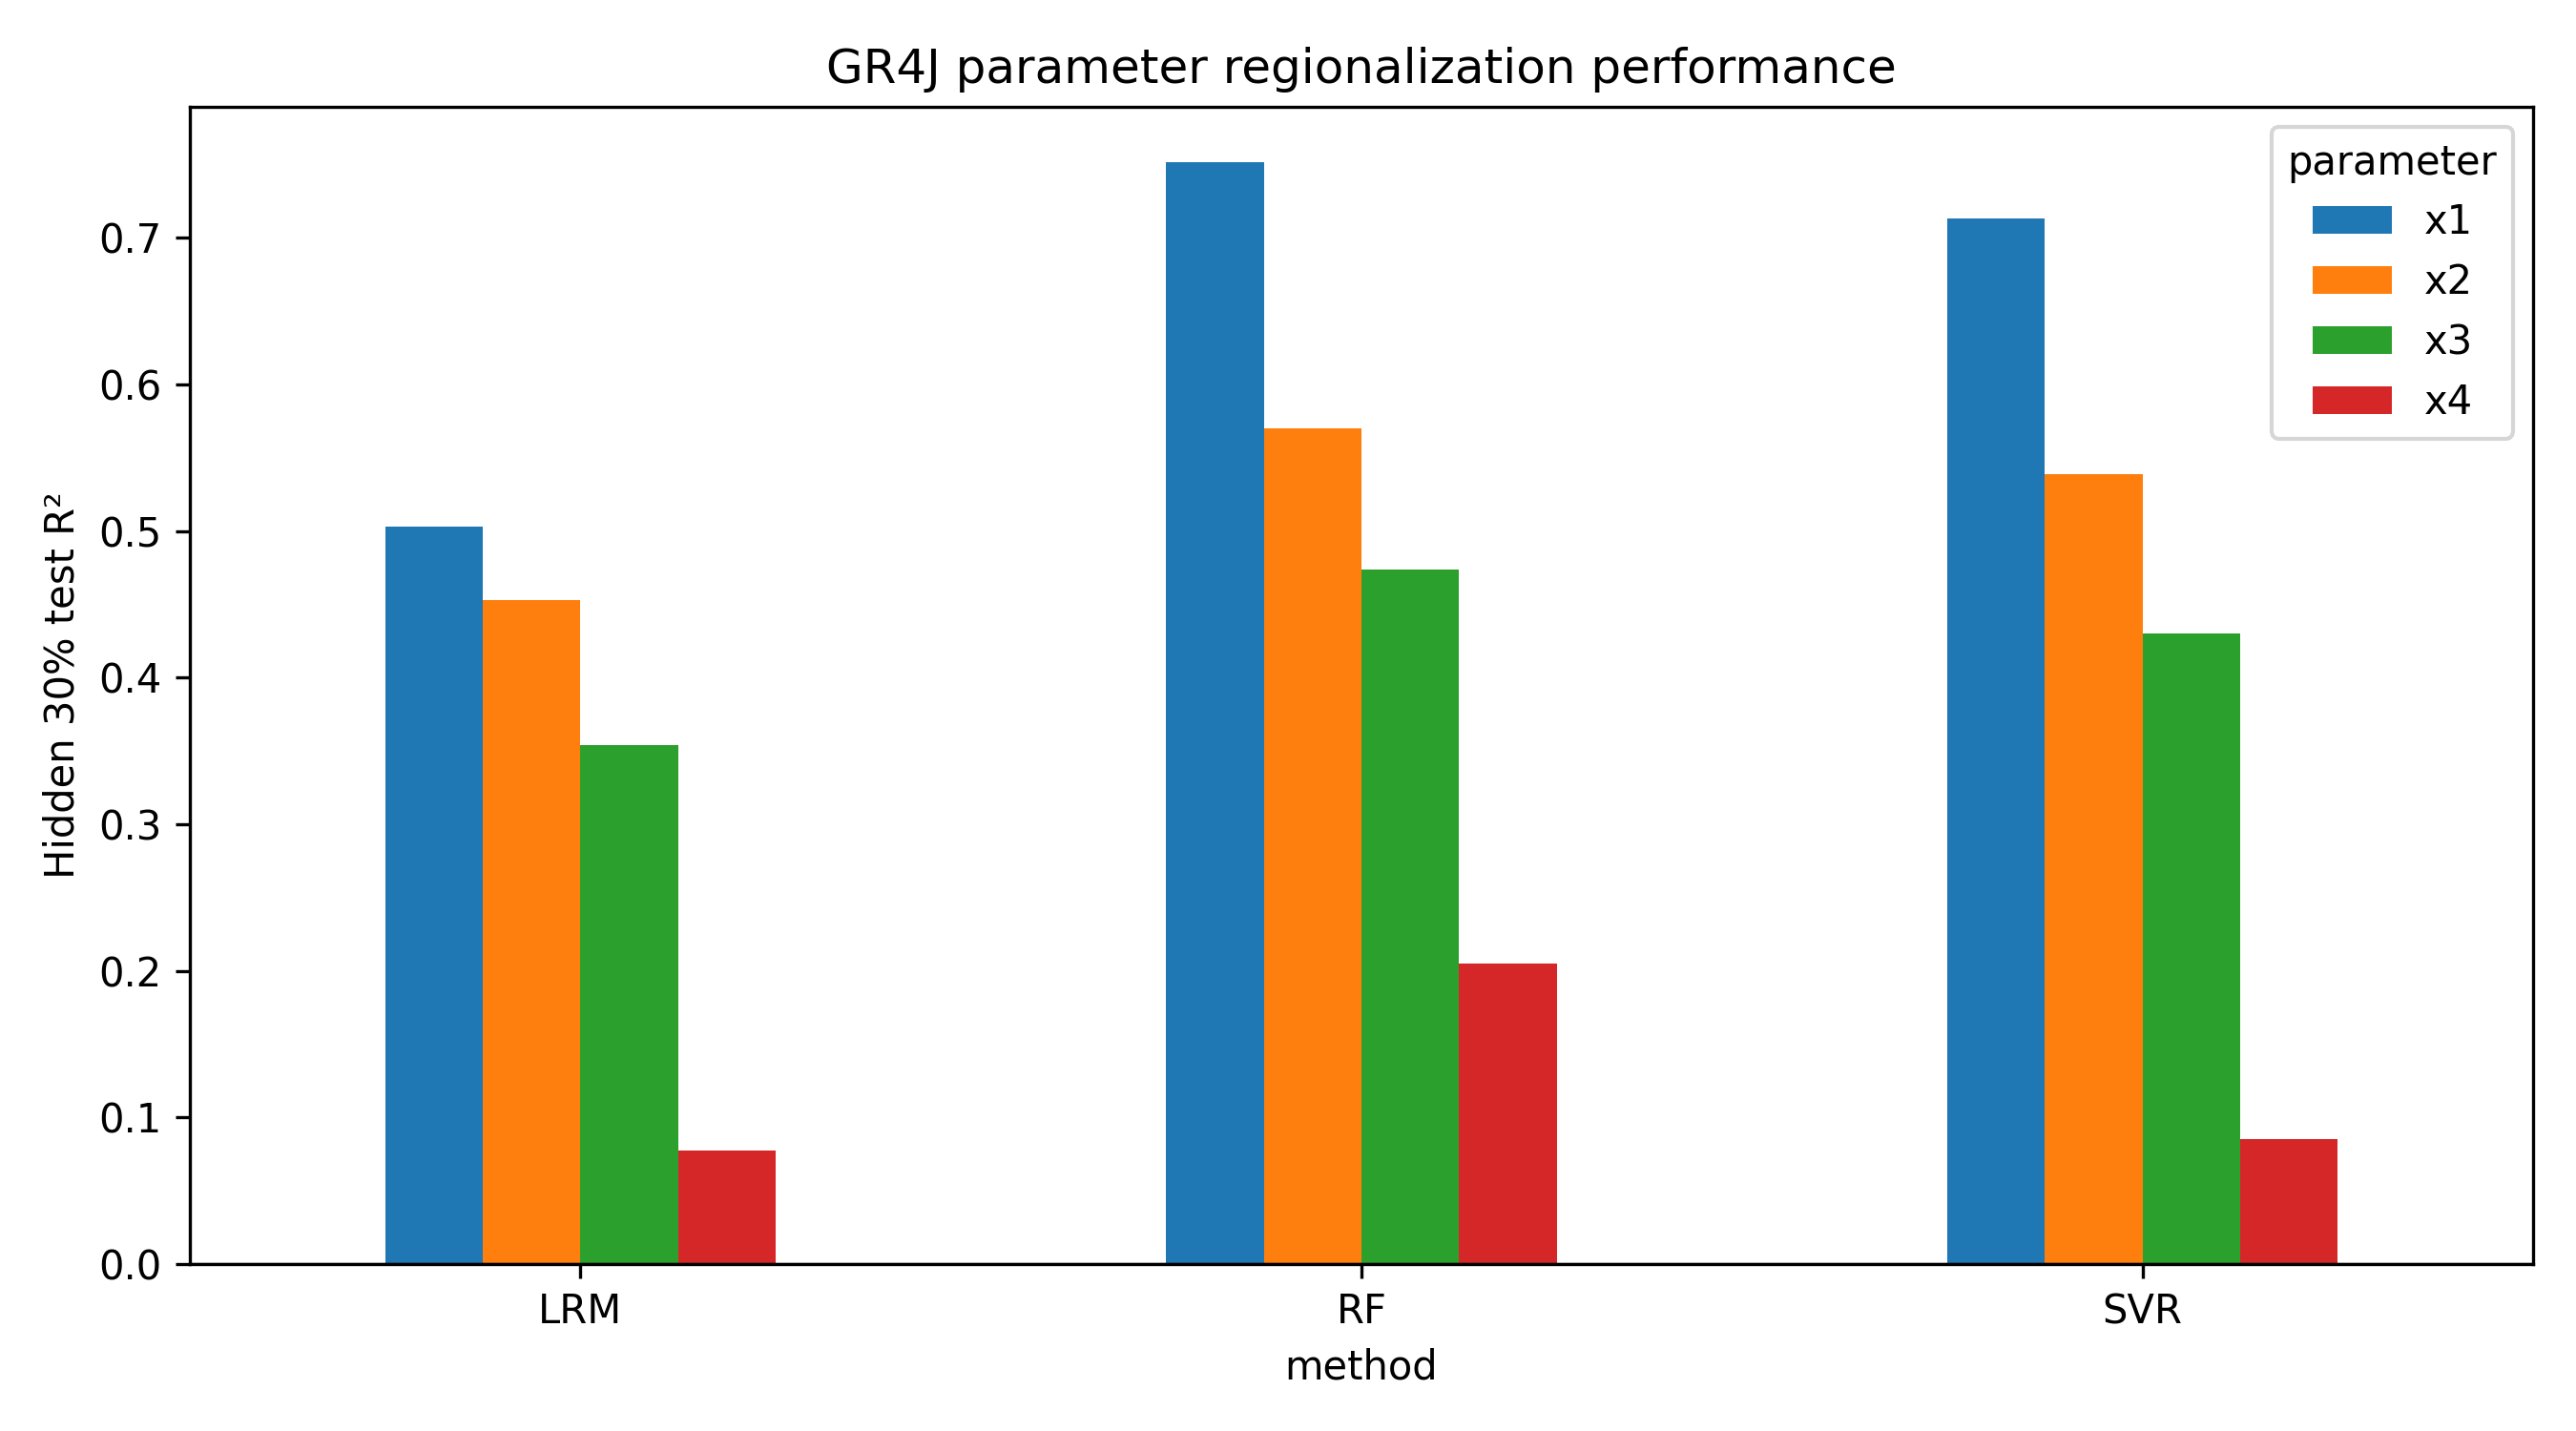

## Linear Regression

### Linear Regression - Updated descriptor matrix

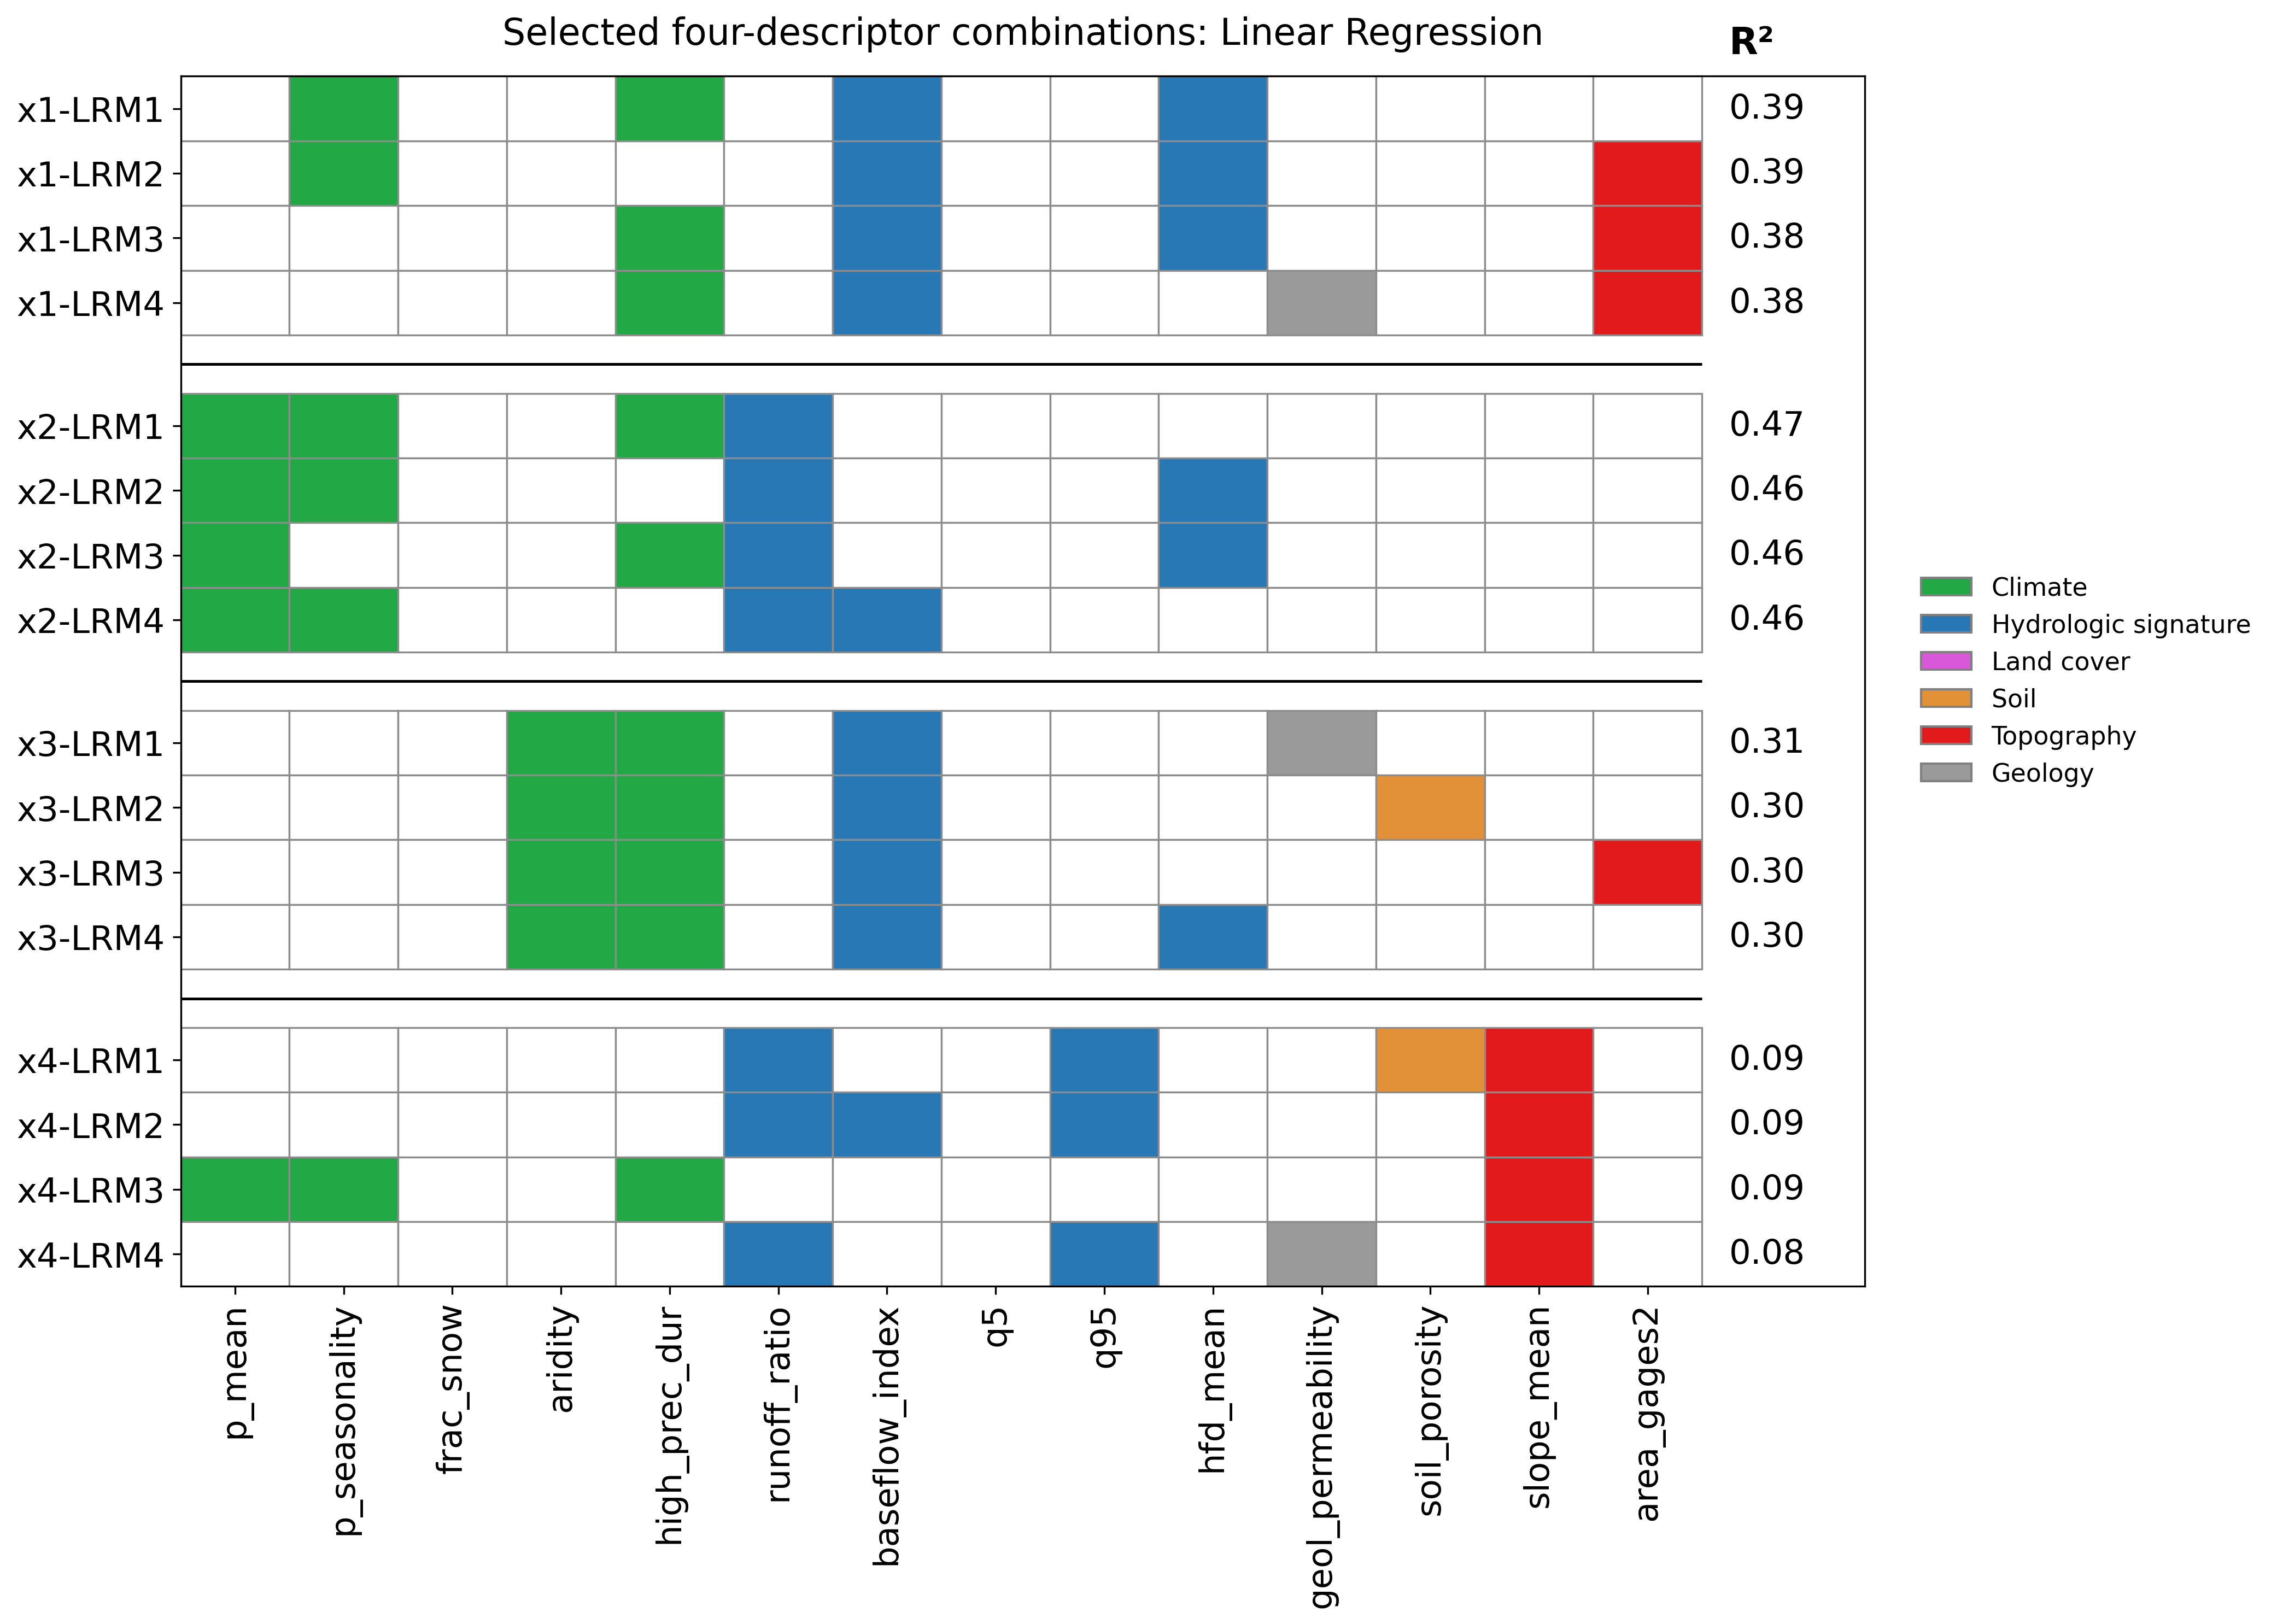

### Linear Regression - Calibrated vs predicted scatter

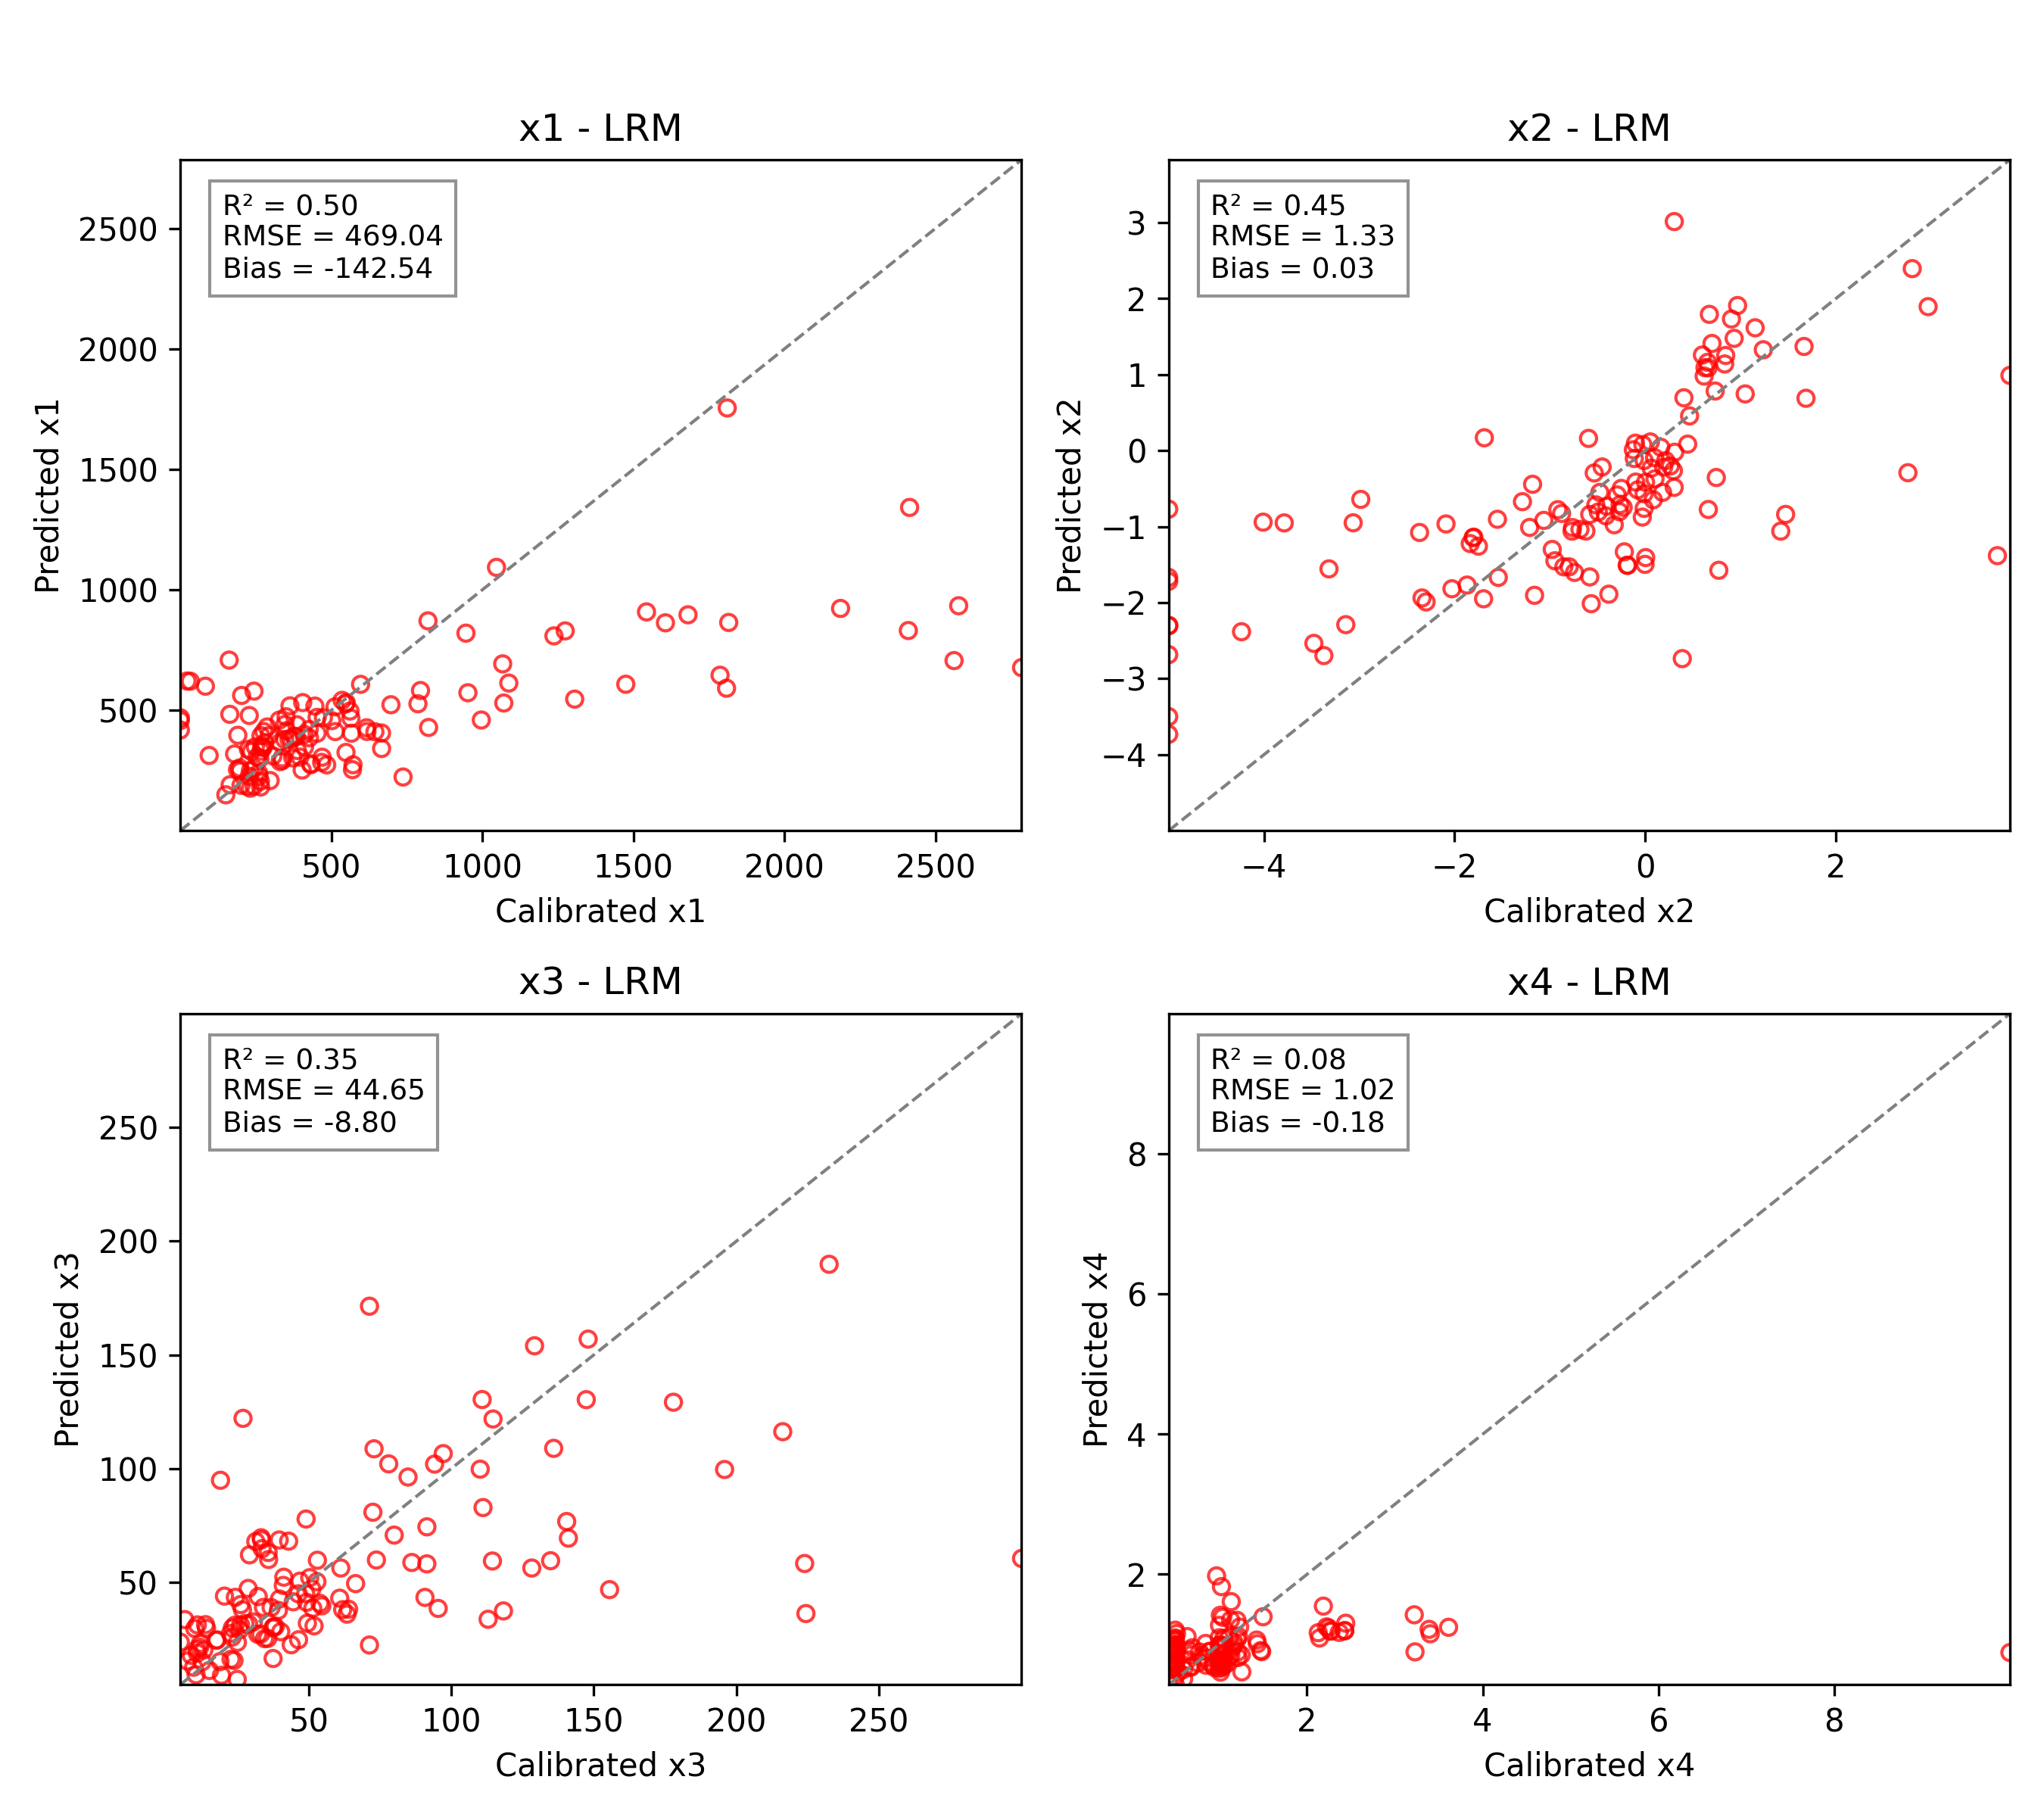

## Random Forest

### Random Forest - Updated descriptor matrix

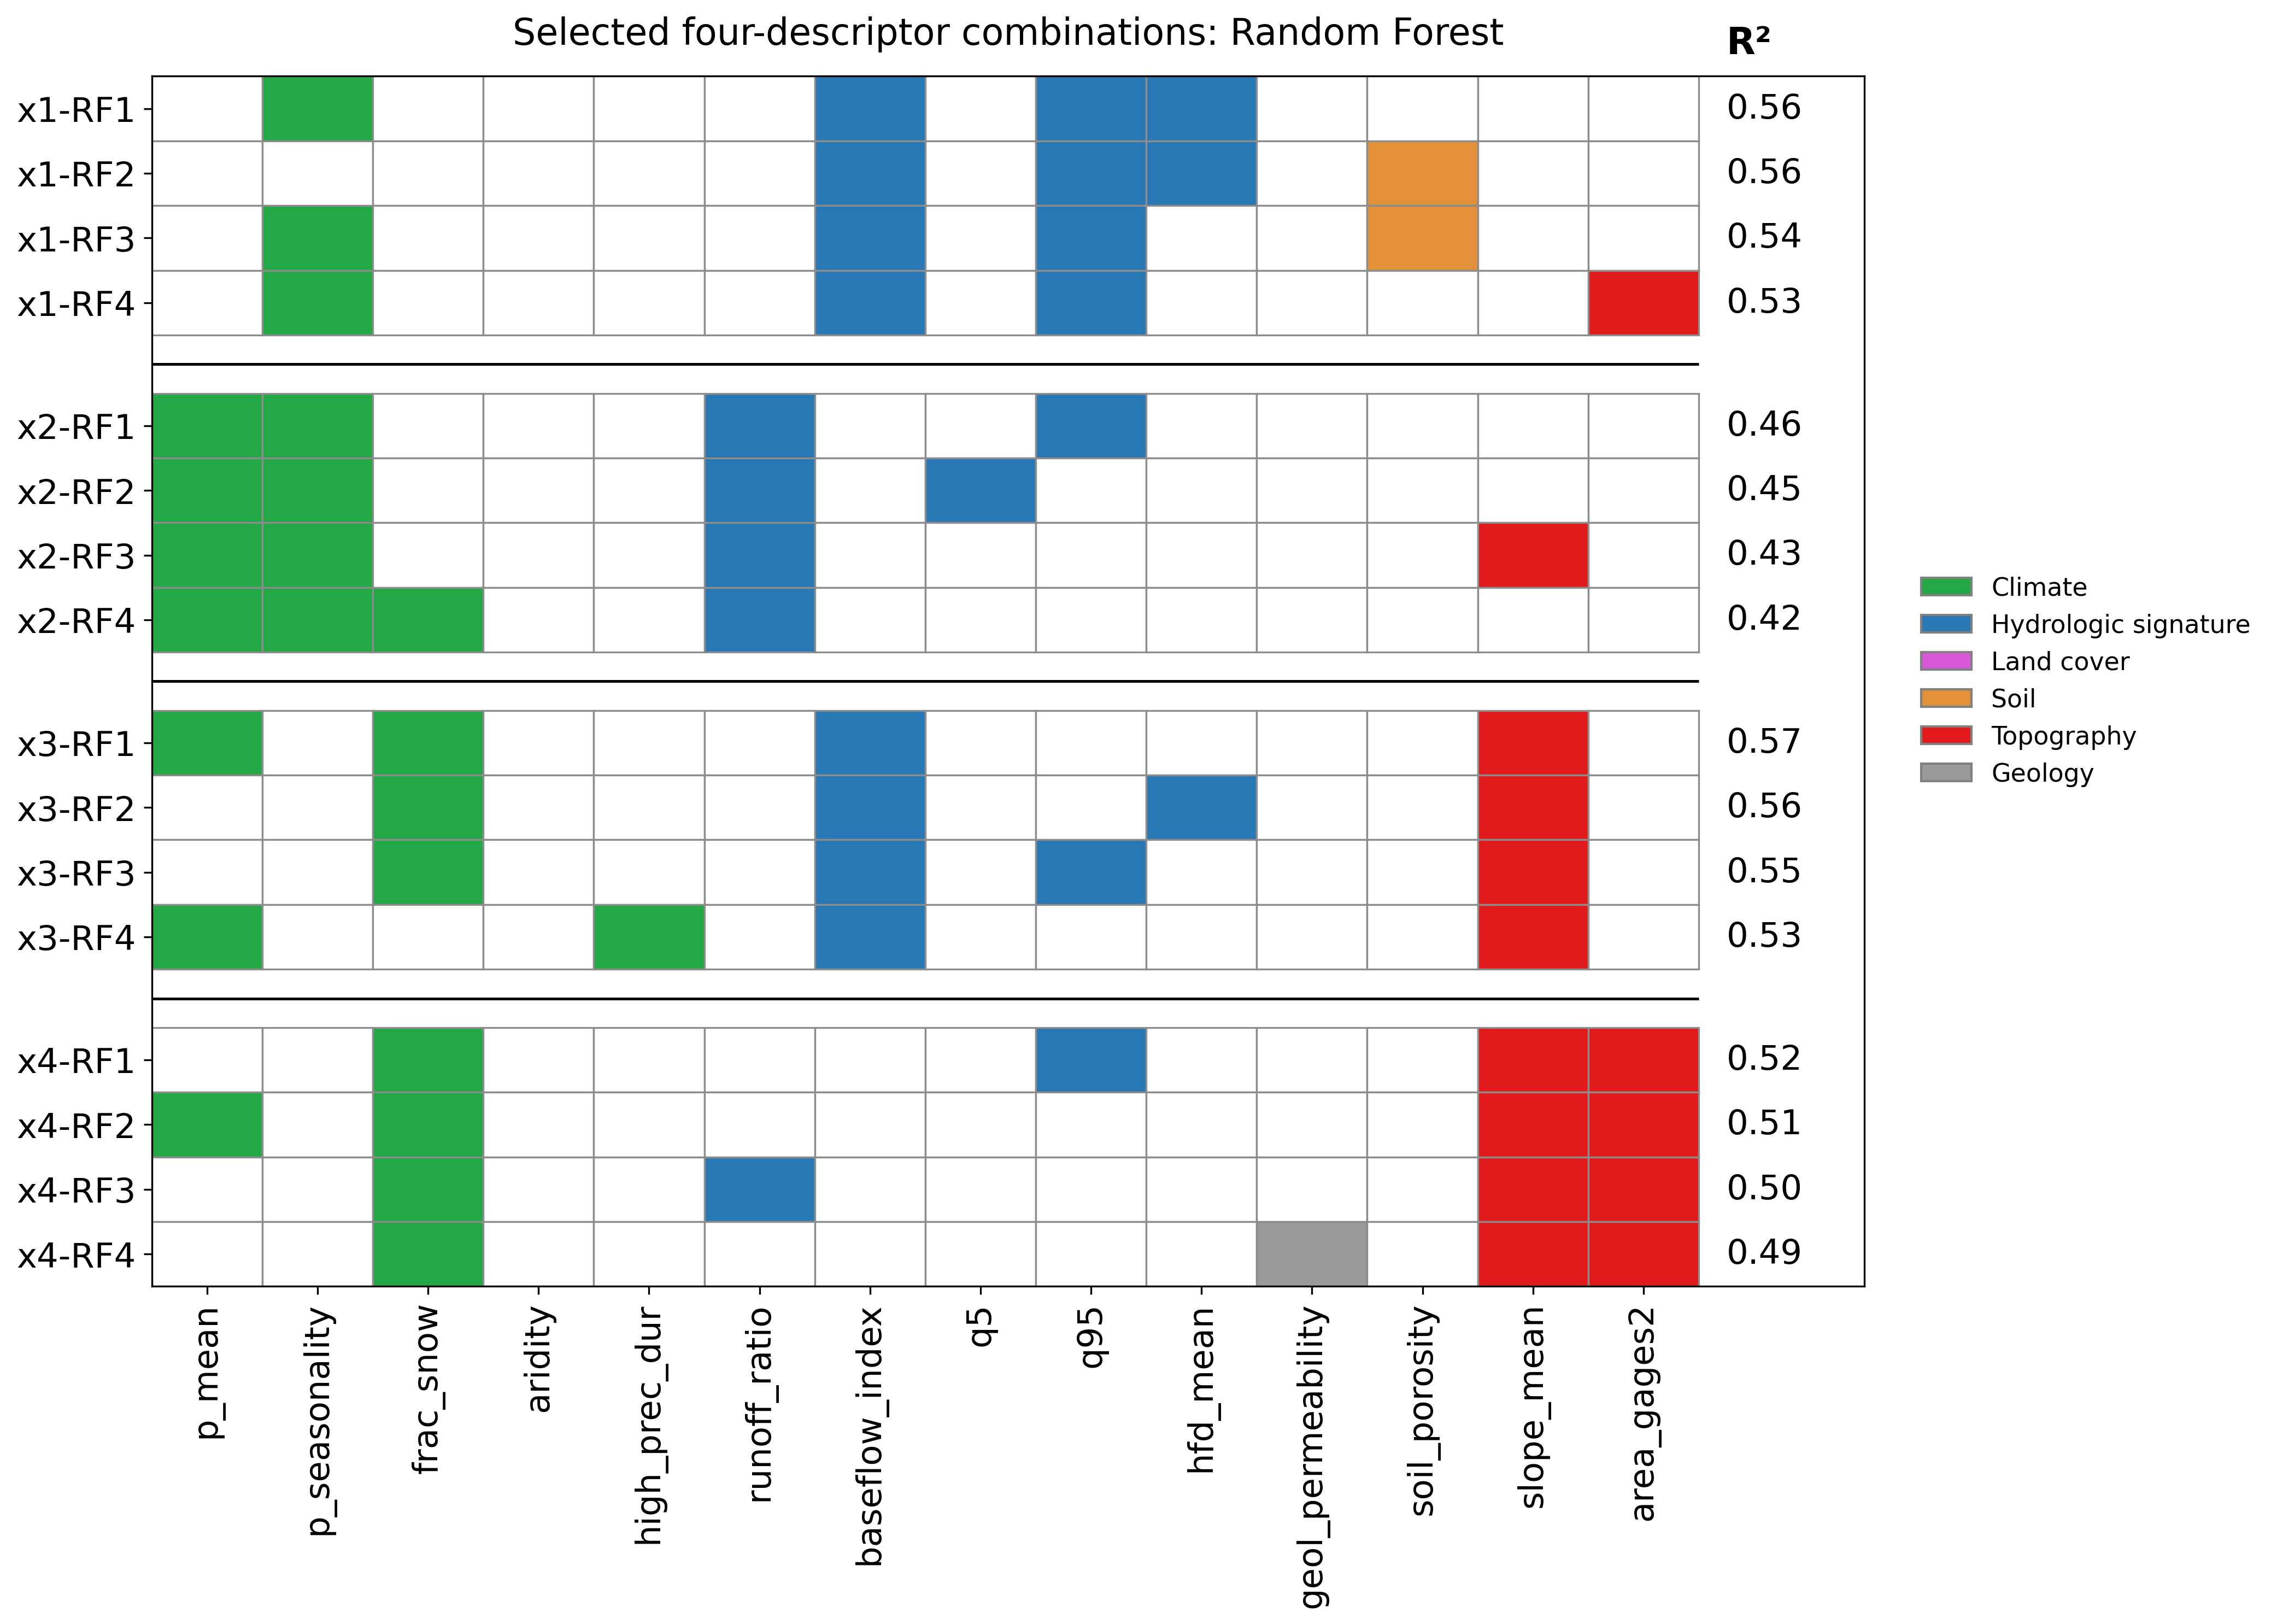

### Random Forest - Calibrated vs predicted scatter

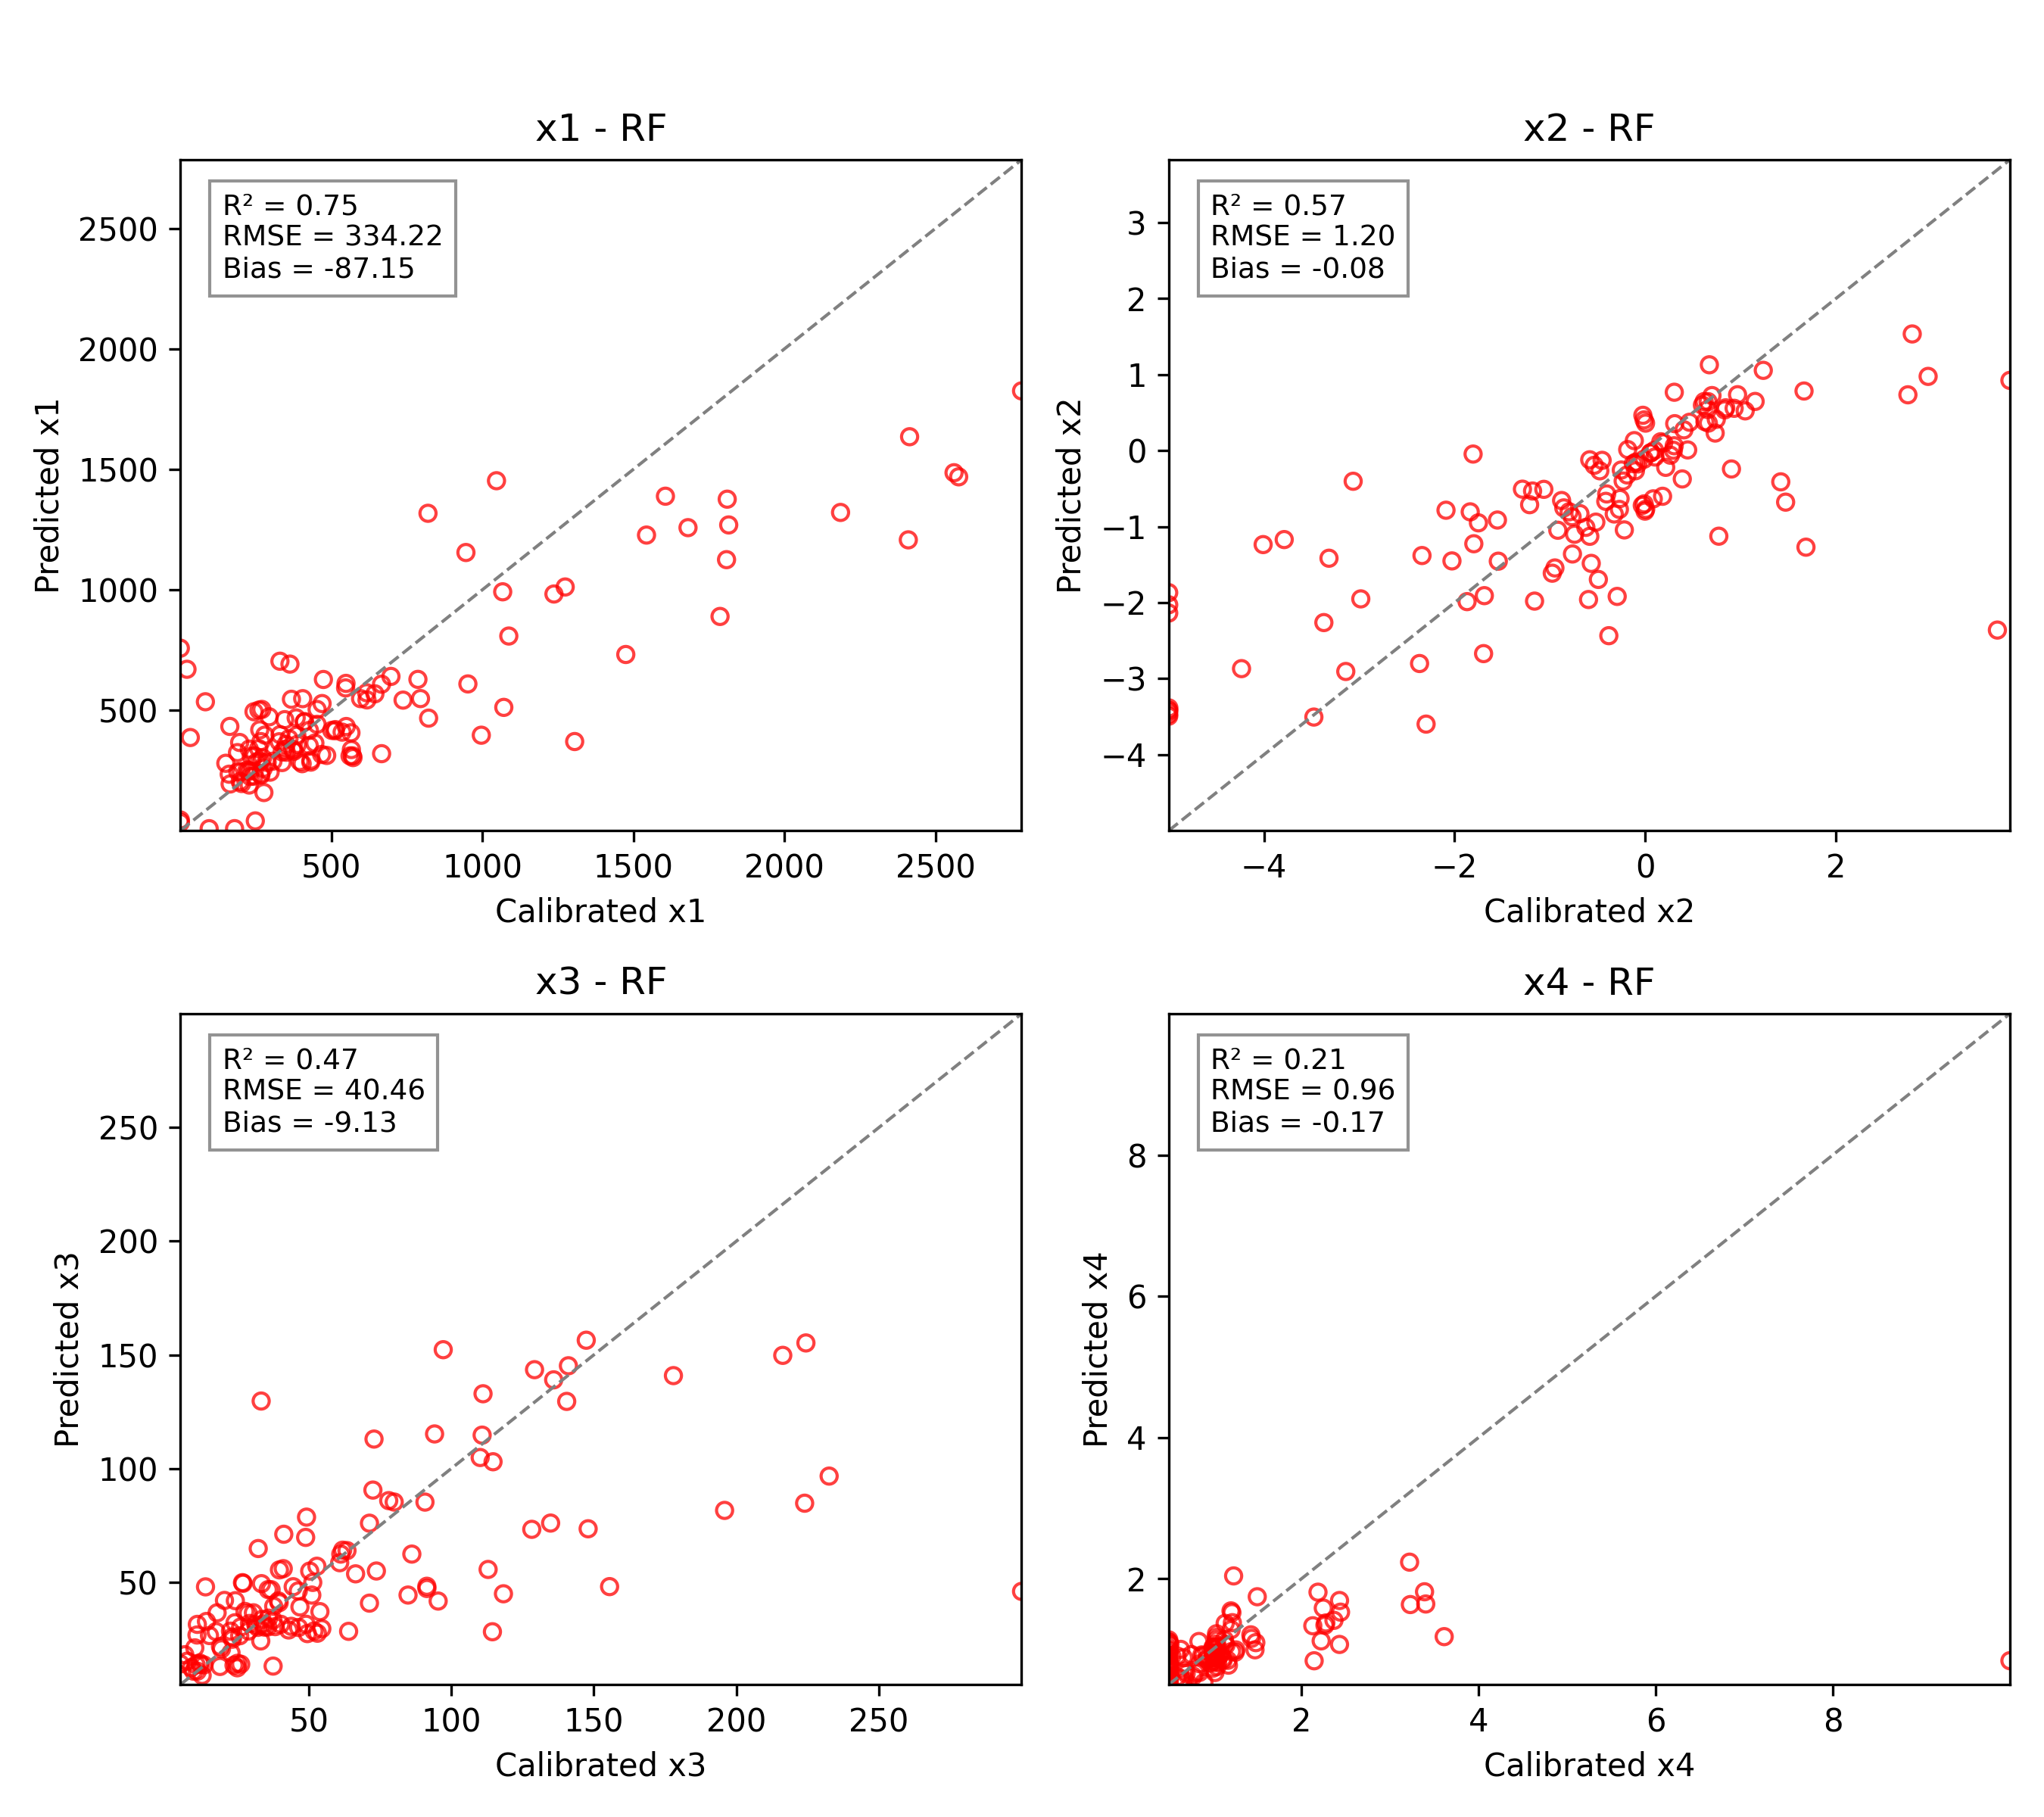

## Support Vector Regression

### Support Vector Regression - Updated descriptor matrix

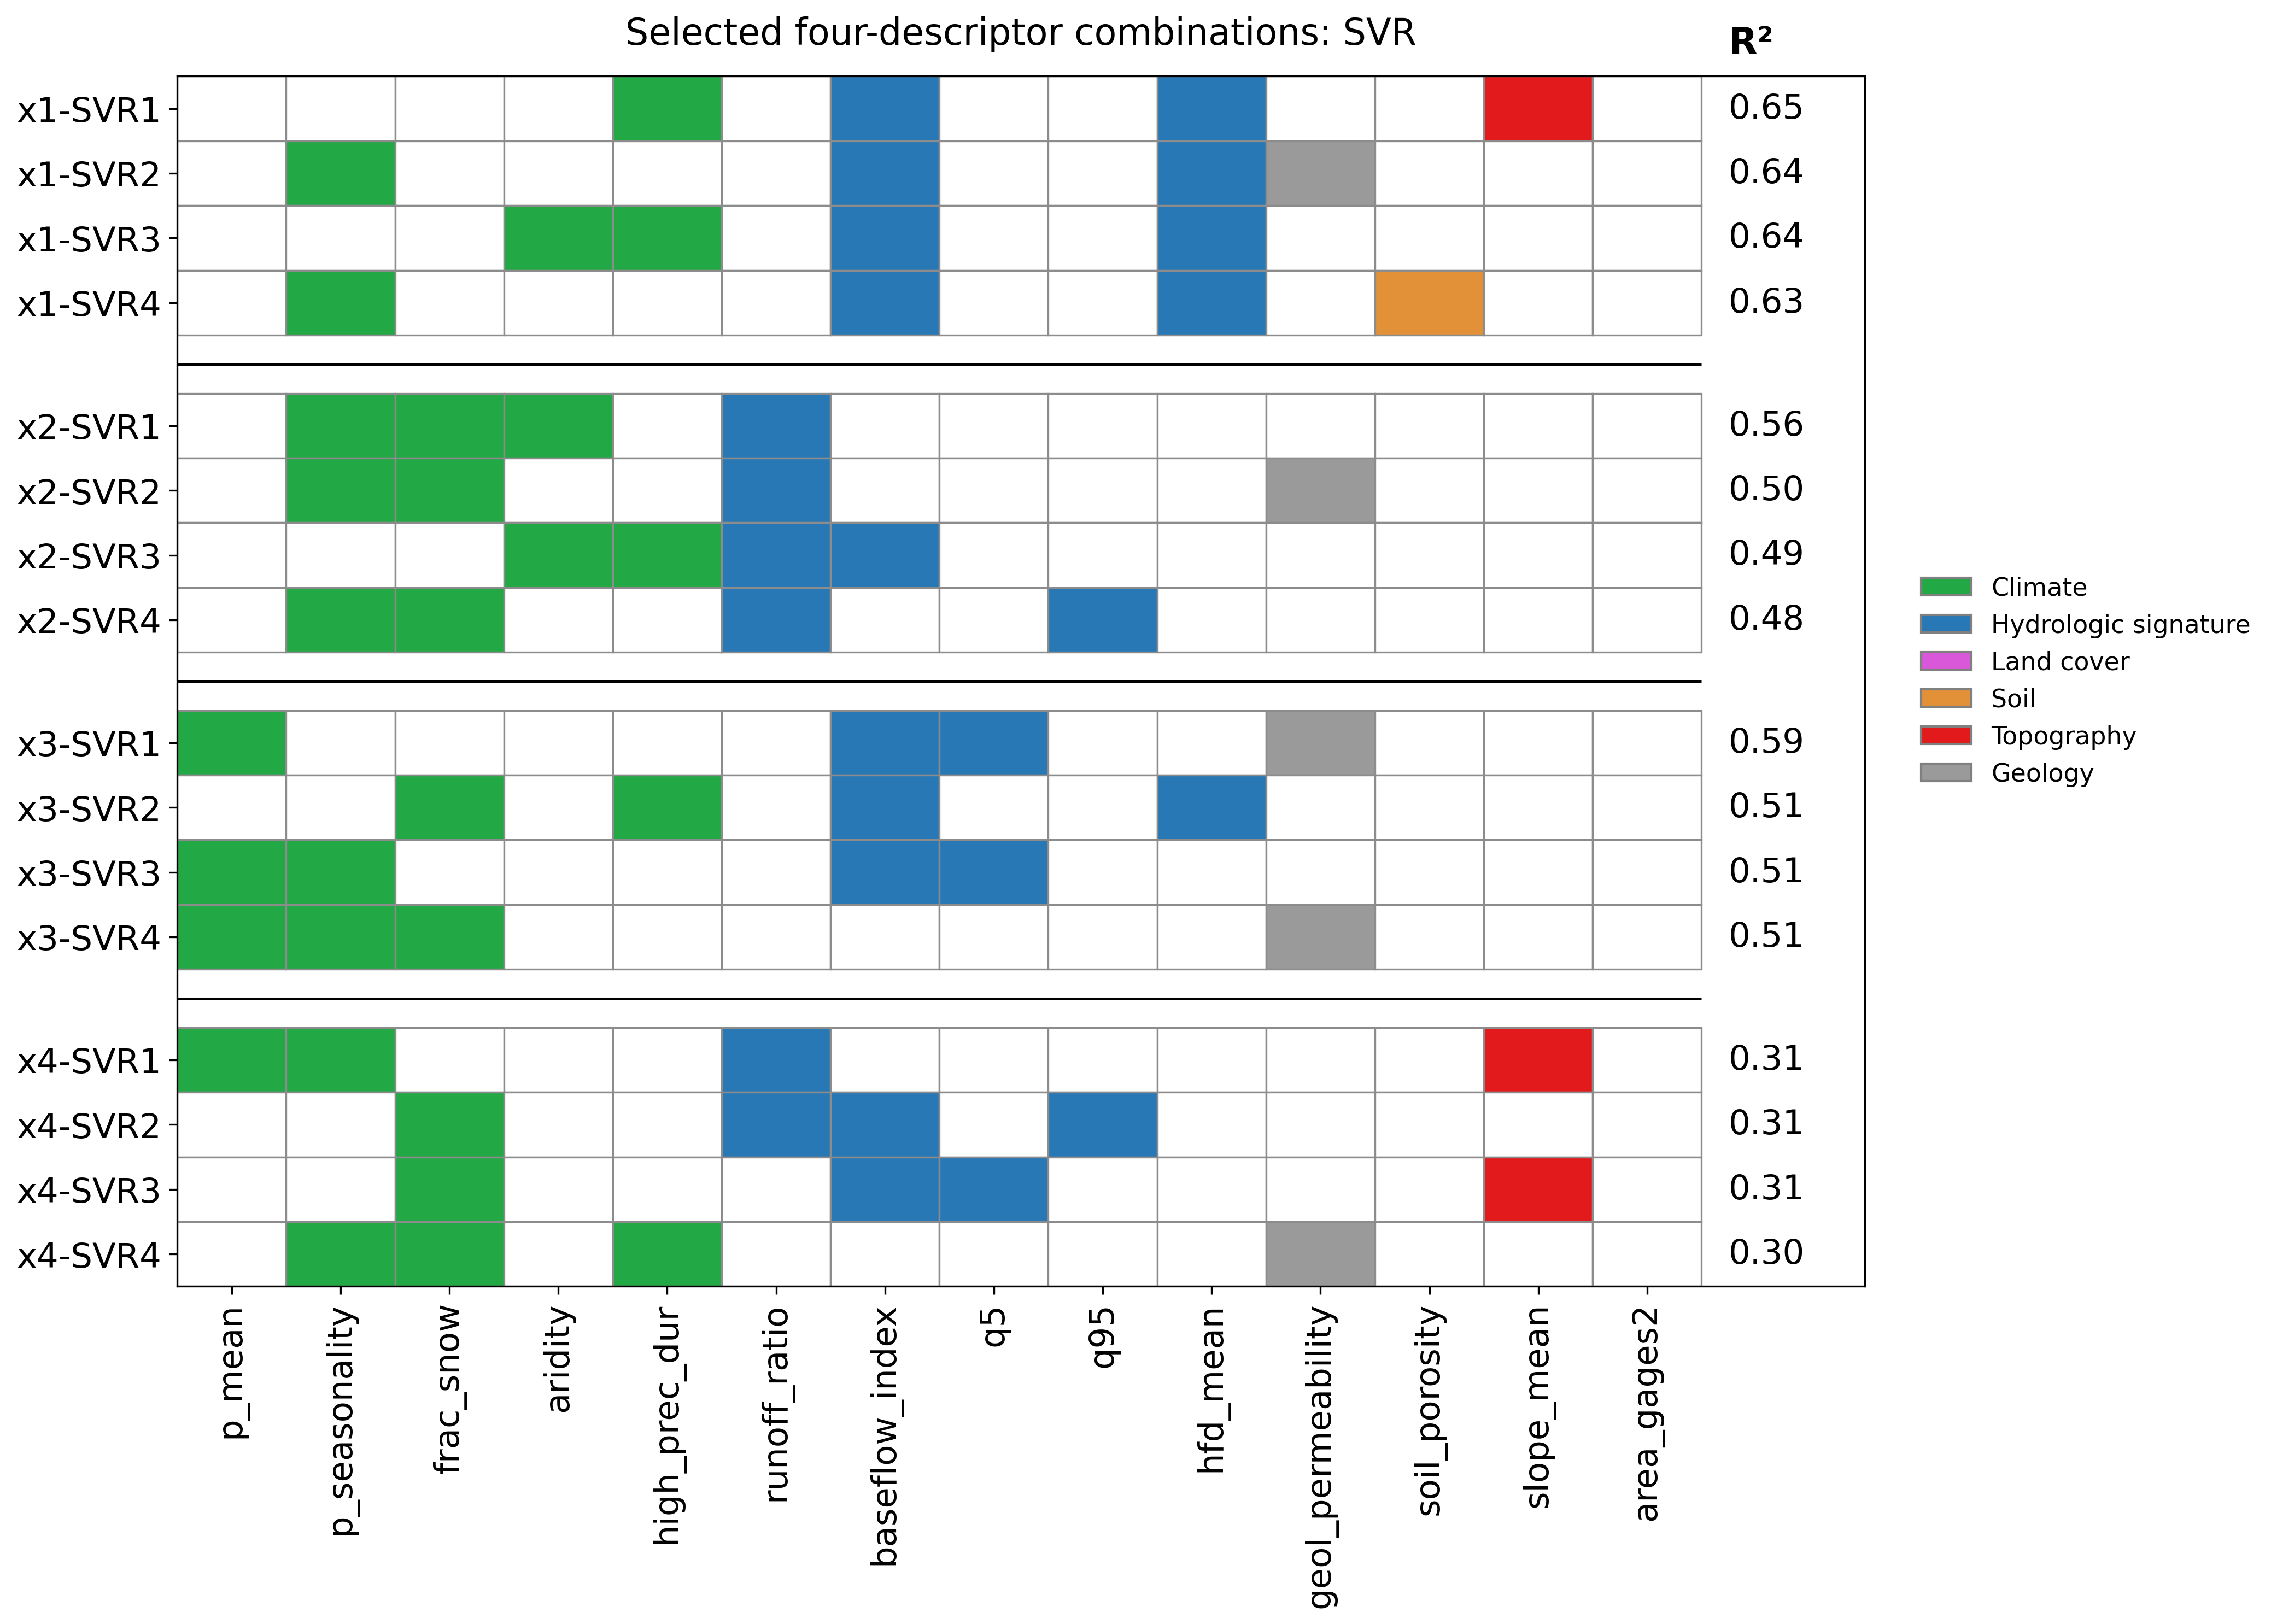

### Support Vector Regression - Calibrated vs predicted scatter

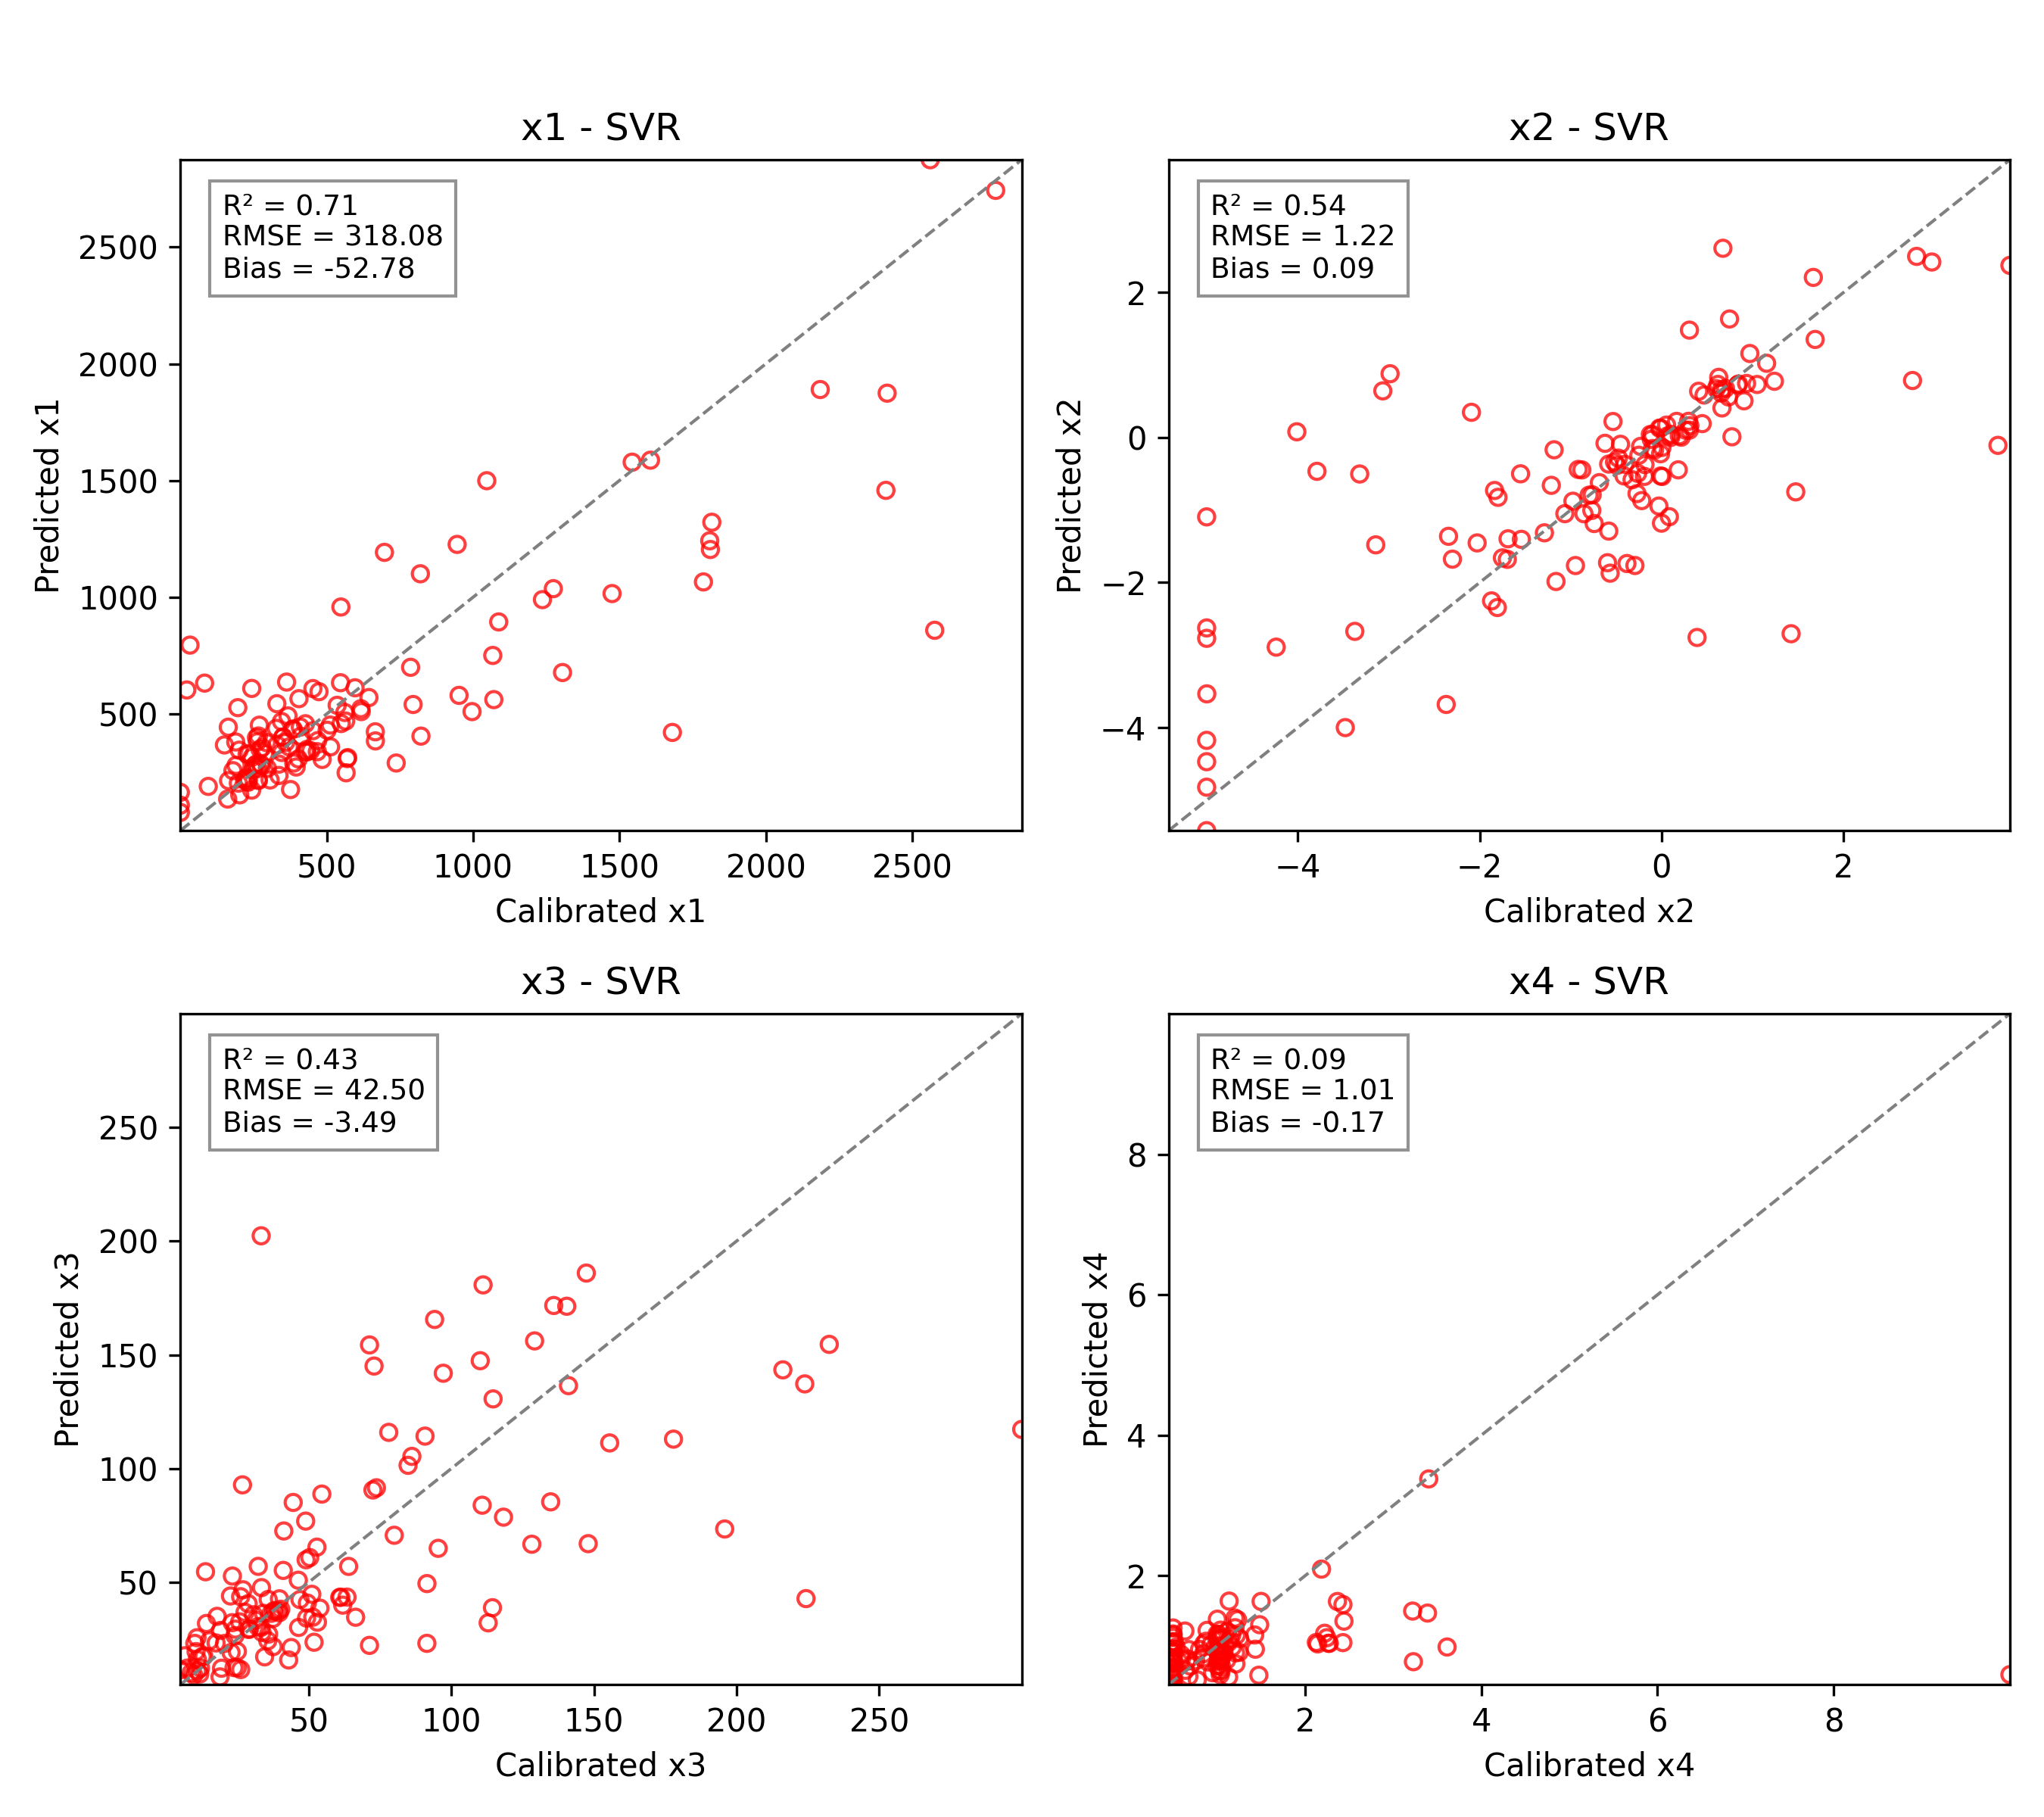

In [13]:
from IPython.display import display, Markdown, Image
from pathlib import Path

OUTDIR = Path("gr4j_final_output")

figures = [
    ("## Overall model comparison", OUTDIR / "ALL_METHODS_hidden30_r2_barplot.png"),

    ("## Linear Regression", None),
    ("### Linear Regression - Updated descriptor matrix", OUTDIR / "LRM_selected_top4_combinations_UPDATED_spaced.png"),
    ("### Linear Regression - Calibrated vs predicted scatter", OUTDIR / "LRM_calibrated_vs_predicted_scatter.png"),

    ("## Random Forest", None),
    ("### Random Forest - Updated descriptor matrix", OUTDIR / "RF_selected_top4_combinations_UPDATED_spaced.png"),
    ("### Random Forest - Calibrated vs predicted scatter", OUTDIR / "RF_calibrated_vs_predicted_scatter.png"),

    ("## Support Vector Regression", None),
    ("### Support Vector Regression - Updated descriptor matrix", OUTDIR / "SVR_selected_top4_combinations_UPDATED_spaced.png"),
    ("### Support Vector Regression - Calibrated vs predicted scatter", OUTDIR / "SVR_calibrated_vs_predicted_scatter.png"),
]

for title, filepath in figures:
    display(Markdown(title))
    if filepath is not None:
        if filepath.exists():
            display(Image(filename=str(filepath)))
        else:
            display(Markdown(f"**Missing file:** `{filepath.name}`"))